<a href="https://colab.research.google.com/github/anaibafoibur/tesina-conexiones-edificio-madera/blob/main/TESINA_LIMPIO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PARTE 1 Carga de datos

In [53]:
import pandas as pd

# ──  PARTE 1 Carga de datos desde repositorio ──────────────────────────
BASE_URL = "https://raw.githubusercontent.com/anaibafoibur/tesina-conexiones-edificio-madera/main/datos/processed"

archivos = {
    "Ed_C_5_Pisos":  f"{BASE_URL}/Ed_C_5_Pisos.csv",
    "Ed_C_6_Pisos":  f"{BASE_URL}/Ed_C_6_Pisos.csv",
    "Ed_D_5_Pisos":  f"{BASE_URL}/Ed_D_5_Pisos.csv",
    "Ed_P1_5_Pisos": f"{BASE_URL}/Ed_P1_5_Pisos.csv",
    "Ed_P1_6_Pisos": f"{BASE_URL}/Ed_P1_6_Pisos.csv",
    "Ed_P2_5_Pisos": f"{BASE_URL}/Ed_P2_5_Pisos.csv",
}

# Leer y consolidar en un único dataframe
dfs = []
for nombre, url in archivos.items():
    df_temp = pd.read_csv(url)
    df_temp["PLANILLA"] = nombre
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

print(f"Dataset consolidado: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dataset consolidado: 24168 filas x 26 columnas


,ID,PLANILLA,DISENO,PISO,DIRECCION,D+0.25L,Tx(s),Ty(s),Qmin,Qmax,...,yi [cm],Espaciamiento de clavos [cm],Cantidad de Tableros OSB,#PPDD de Borde externos,#PPDD de Borde internos,Espaciamiento,# PPDD total,Diametro ATS [cm],Unnamed: 24,Unnamed: 25
0,NaN,Ed_C_5_Pisos,C_5_0.004_6.5_D_II_3_MGP10_ATS,1,X,89642.005003,0.450406,0.453642,NaN,NaN,...,0.0,5,2,3,3,20.0,13,3.1750,NaN,NaN
1,NaN,Ed_C_5_Pisos,C_5_0.004_6.5_D_II_3_MGP10_ATS,1,X,89642.005003,0.450406,0.453642,NaN,NaN,...,0.0,5,2,3,3,20.0,13,3.1750,NaN,NaN
2,NaN,Ed_C_5_Pisos,C_5_0.004_6.5_D_II_3_MGP10_ATS,1,X,89642.005003,0.450406,0.453642,NaN,NaN,...,122.8,5,2,3,3,20.0,13,3.1750,NaN,NaN
3,NaN,Ed_C_5_Pisos,C_5_0.004_6.5_D_II_3_MGP10_ATS,1,X,89642.005003,0.450406,0.453642,NaN,NaN,...,122.8,5,2,3,3,20.0,17,2.8575,NaN,NaN
4,NaN,Ed_C_5_Pisos,C_5_0.004_6.5_D_II_3_MGP10_ATS,1,X,89642.005003,0.450406,0.453642,NaN,NaN,...,122.8,5,2,3,3,20.0,13,3.1750,NaN,NaN


PARTE 2: VISTA DEL DATASET Y LIMPIEZA DE DATOS

In [54]:
# ─────────────────────────────────────────────────────────────
# BLOQUE 2: VISTA GENERAL DEL DATASET Y LIMPIEZA INICIAL
# ─────────────────────────────────────────────────────────────

# 2.1 Tipos de datos y valores nulos
print("=" * 50)
print("TIPOS DE DATOS Y NULOS")
print("=" * 50)
df.info()

print("\nVALORES NULOS POR COLUMNA")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "Sin valores nulos ✓")

# 2.2 Eliminar columnas que no se utilizan en el análisis
# - ID: viene vacío desde el CSV, se reemplaza por correlativo
# - Qmin y Qmax: casi completamente vacías (solo 63 de 24.168 registros)
# - Unnamed: 24 y 25: columnas vacías generadas al exportar el CSV
columnas_a_eliminar = ["ID", "Qmin", "Qmax", "Unnamed: 24", "Unnamed: 25"]
df = df.drop(columns=columnas_a_eliminar, errors="ignore")

# 2.3 Imputar el único nulo en D+0.25L con la mediana
df["D+0.25L"] = df["D+0.25L"].fillna(df["D+0.25L"].median())

# 2.4 Crear ID correlativo como identificador único de cada muro
df.insert(0, "ID", range(1, len(df) + 1))

# 2.5 Verificar que no queden nulos
print("\nVALORES NULOS TRAS LIMPIEZA")
nulos_post = df.isnull().sum()
print(nulos_post[nulos_post > 0] if nulos_post.sum() > 0 else "Sin valores nulos ✓")

print(f"\nColumnas finales: {df.shape[1]}")
print(df.columns.tolist())

# 2.6 Distribución de la variable objetivo
print("\n" + "=" * 50)
print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO: Diametro ATS [cm]")
print("=" * 50)
tabla = df["Diametro ATS [cm]"].value_counts().reset_index()
tabla.columns = ["Diametro ATS [cm]", "Cantidad"]
tabla["Porcentaje (%)"] = (tabla["Cantidad"] / len(df) * 100).round(2)
tabla = tabla.sort_values("Diametro ATS [cm]").reset_index(drop=True)
print(tabla.to_string(index=False))

TIPOS DE DATOS Y NULOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24168 entries, 0 to 24167
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            0 non-null      float64
 1   PLANILLA                      24168 non-null  object 
 2   DISENO                        24168 non-null  object 
 3   PISO                          24168 non-null  int64  
 4   DIRECCION                     24168 non-null  object 
 5   D+0.25L                       24167 non-null  float64
 6   Tx(s)                         24168 non-null  float64
 7   Ty(s)                         24168 non-null  float64
 8   Qmin                          63 non-null     float64
 9   Qmax                          63 non-null     float64
 10  Qx[tonf]                      24168 non-null  float64
 11  Qy[tonf]                      24168 non-null  float64
 12  AREA PLANTA                   24168 n

PARTE 3) Cálculo de parámetro SUM_largo_eje para después poder hacer el modelo de regresión para la densidad de muros

In [55]:
# ─────────────────────────────────────────────────────────────
# BLOQUE 3: TRANSFORMACIONES Y VARIABLES DERIVADAS
# ─────────────────────────────────────────────────────────────

# 3.1 Extraer atributos desde la columna DISENO
# El nombre del diseño codifica los parámetros sísmicos usados,
# con el formato: TipoEdificio_Npisos_Drift_R_Suelo_Zona1_Zona2_Material_Ancla
# Ejemplo: C_5_0.004_6.5_D_II_3_MGP10_ATS
diseno_colum = df["DISENO"].str.split("_", expand=True)

df["Tipo_de_edificio"] = diseno_colum[0]
df["Nro_pisos"]        = diseno_colum[1]
df["Drift"]            = diseno_colum[2]
df["R"]                = diseno_colum[3]
df["Tipo_Suelo"]       = diseno_colum[4]
df["Zona_sismica"]     = diseno_colum[6]

# 3.2 Filtrar filas con valores válidos en columnas extraídas
# Algunos registros pueden tener valores mal formateados
mask = (
    df["Nro_pisos"].str.match(r'^\d+$') &
    df["Drift"].str.match(r'^\d+\.?\d*$') &
    df["R"].str.match(r'^\d+\.?\d*$')
)

filas_eliminadas = df[~mask]
print(f"Filas eliminadas por formato inválido: {len(filas_eliminadas)}")
df = df[mask].copy()
print(f"Filas restantes: {len(df)}")

# 3.3 Convertir tipos numéricos
df["Nro_pisos"] = df["Nro_pisos"].astype(int)
df["Drift"]     = df["Drift"].astype(float)
df["R"]         = df["R"].astype(float)

# 3.4 Calcular suma del largo de muros por diseño, piso y dirección
# Esta es la variable objetivo del modelo de regresión
df["Sum_L_eje"] = df.groupby(["DISENO", "PISO", "DIRECCION"])["L [cm]"].transform("sum")

# 3.5 Calcular densidad de muro
# Densidad = Sum_L_eje / Área de planta (sin espesor porque es constante)
df["Densidad_muro"] = df["Sum_L_eje"] / df["AREA PLANTA"]

print(f"\nColumnas totales: {df.shape[1]}")
print(df[["DISENO", "PISO", "DIRECCION", "L [cm]", "Sum_L_eje", "Densidad_muro"]].head(10))

Filas eliminadas por formato inválido: 590
Filas restantes: 23578

Columnas totales: 30
                           DISENO  PISO DIRECCION  L [cm]  Sum_L_eje  \
0  C_5_0.004_6.5_D_II_3_MGP10_ATS     1         X   120.0     4924.0   
1  C_5_0.004_6.5_D_II_3_MGP10_ATS     1         X   120.0     4924.0   
2  C_5_0.004_6.5_D_II_3_MGP10_ATS     1         X   127.0     4924.0   
3  C_5_0.004_6.5_D_II_3_MGP10_ATS     1         X   280.0     4924.0   
4  C_5_0.004_6.5_D_II_3_MGP10_ATS     1         X   127.0     4924.0   
5  C_5_0.004_6.5_D_II_3_MGP10_ATS     1         X   205.0     4924.0   
6  C_5_0.004_6.5_D_II_3_MGP10_ATS     1         X   205.0     4924.0   
7  C_5_0.004_6.5_D_II_3_MGP10_ATS     1         X   169.0     4924.0   
8  C_5_0.004_6.5_D_II_3_MGP10_ATS     1         X   169.0     4924.0   
9  C_5_0.004_6.5_D_II_3_MGP10_ATS     1         X   540.0     4924.0   

   Densidad_muro  
0       0.001949  
1       0.001949  
2       0.001949  
3       0.001949  
4       0.001949  
5    

In [56]:
# Recuperar AREA PLANTA numérica desde el dataframe original
# agrupando por DISENO para recuperar el valor correcto
df["AREA PLANTA"] = df.groupby("DISENO")["AREA PLANTA"].transform(
    lambda x: pd.to_numeric(x, errors="coerce").ffill()
)

# Verificar que quedó numérica
print(df["AREA PLANTA"].dtype)
print(df["AREA PLANTA"].isna().sum(), "nulos")
print(df["AREA PLANTA"].unique()[:5])

float64
0 nulos
[2526612.8517 2526612.8517 5302759.5157 4918759.586  4366070.9648]


PARTE 4) Gráficos de exploración de datos

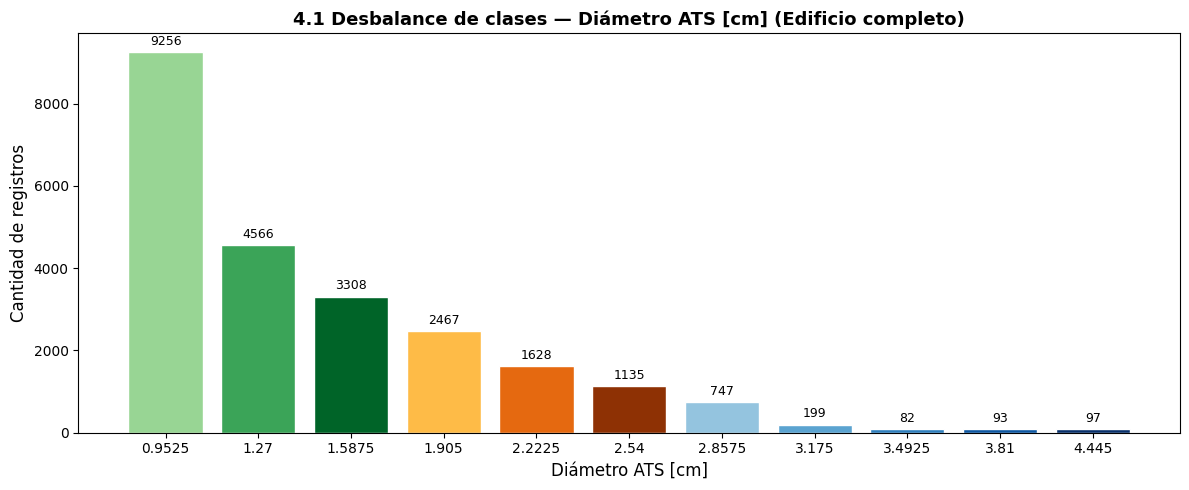

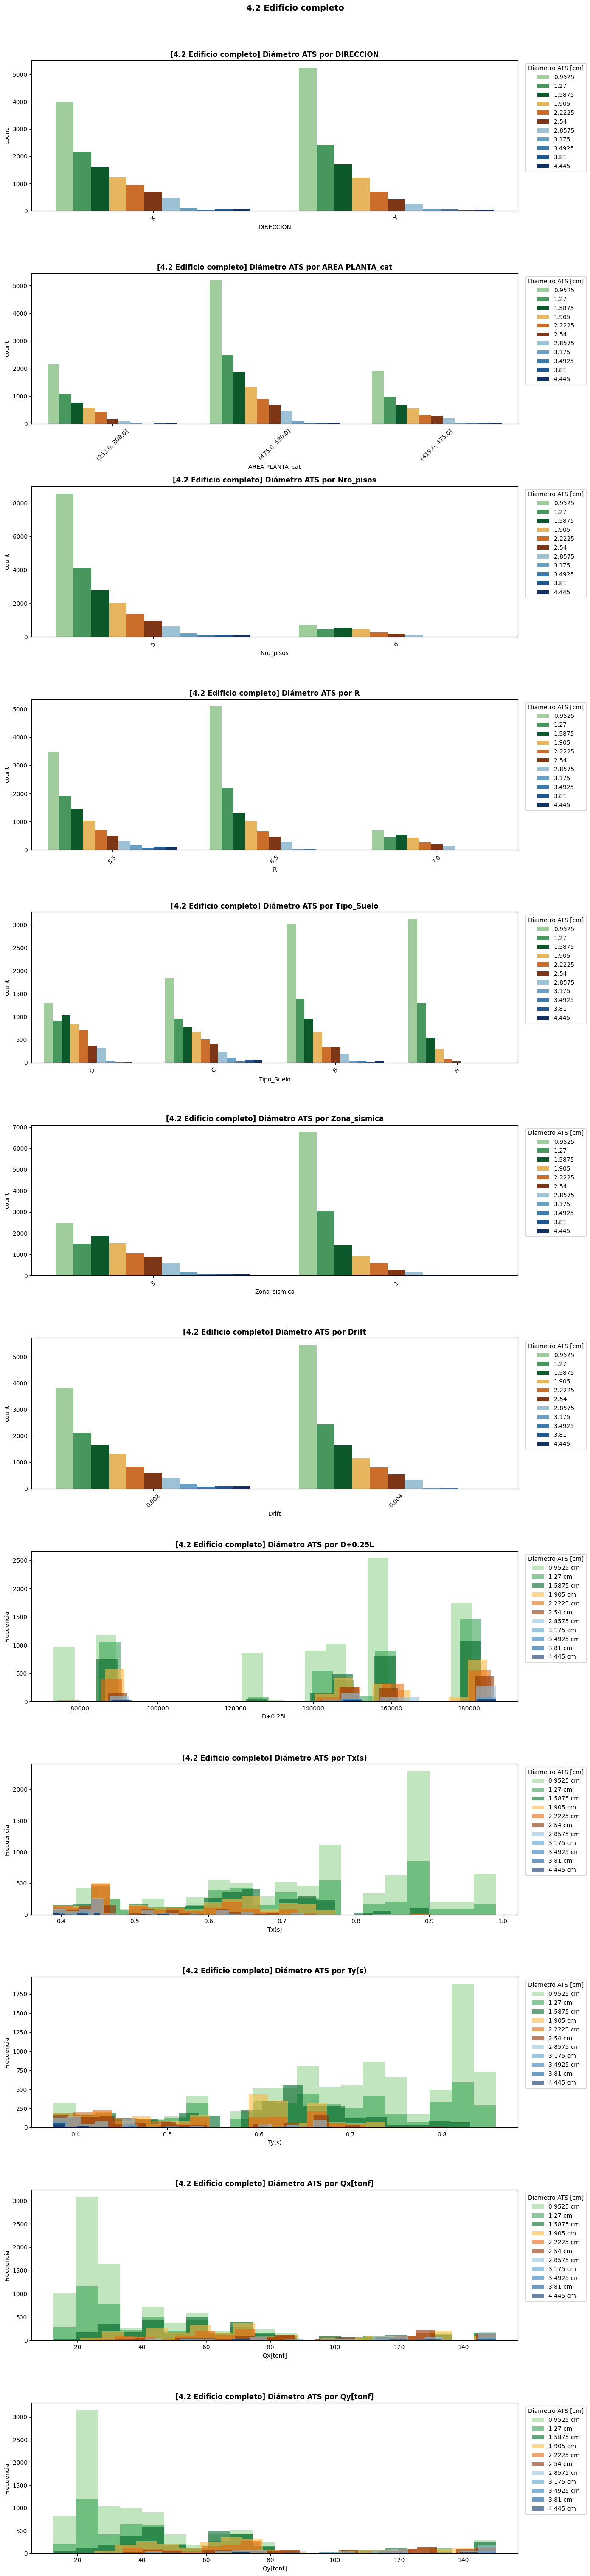

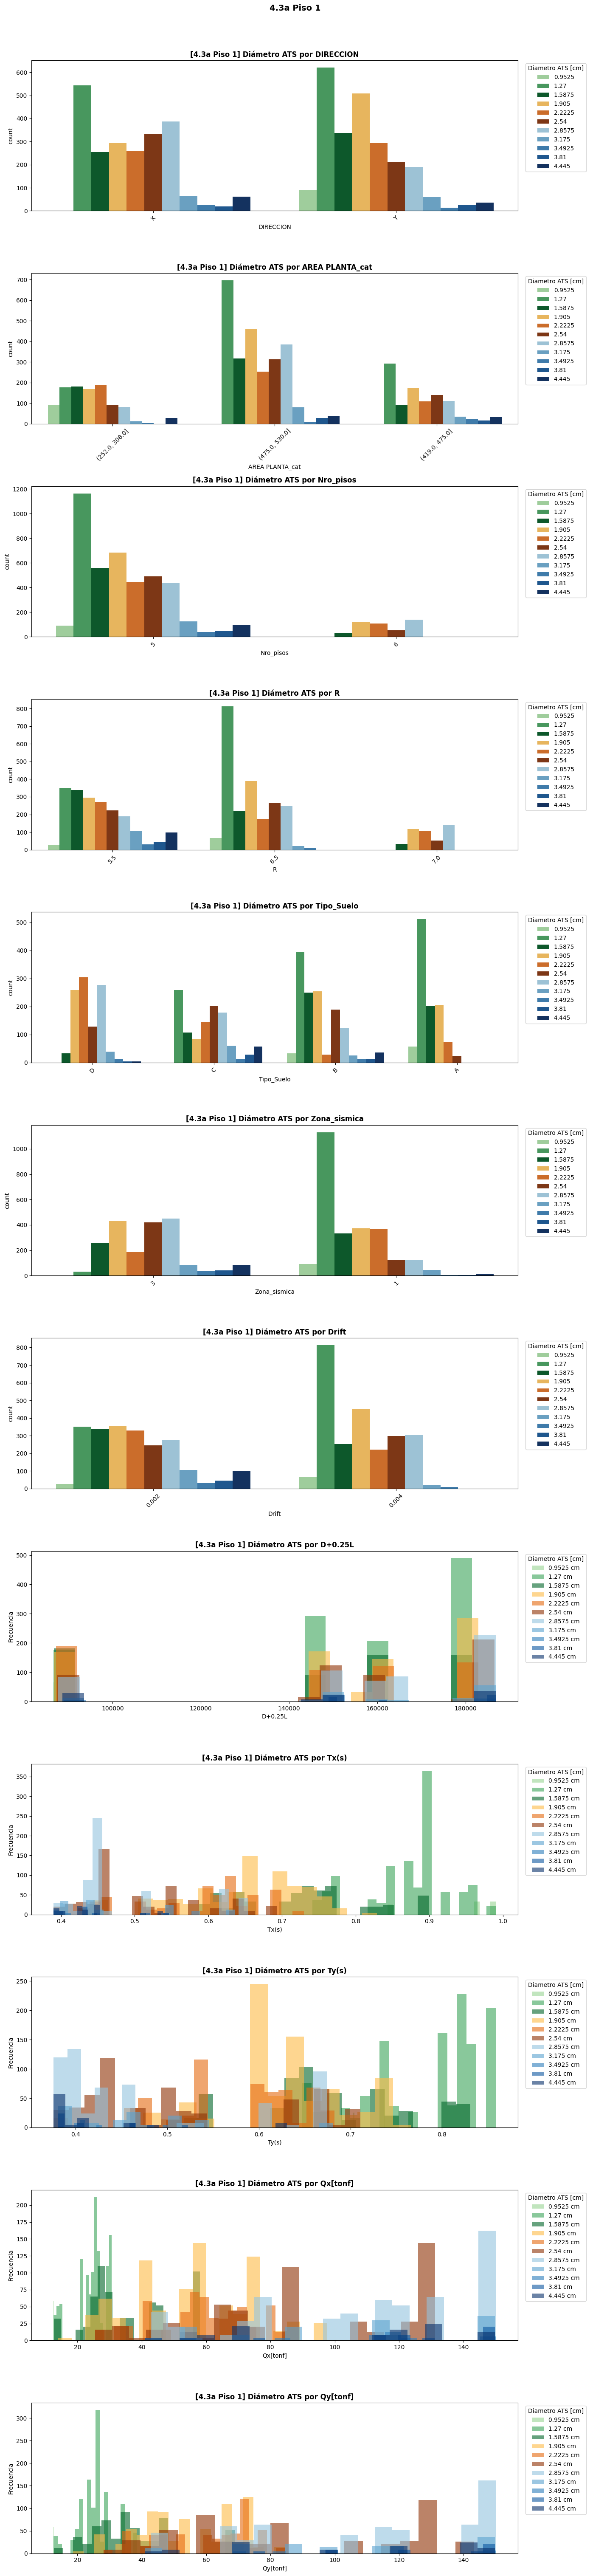

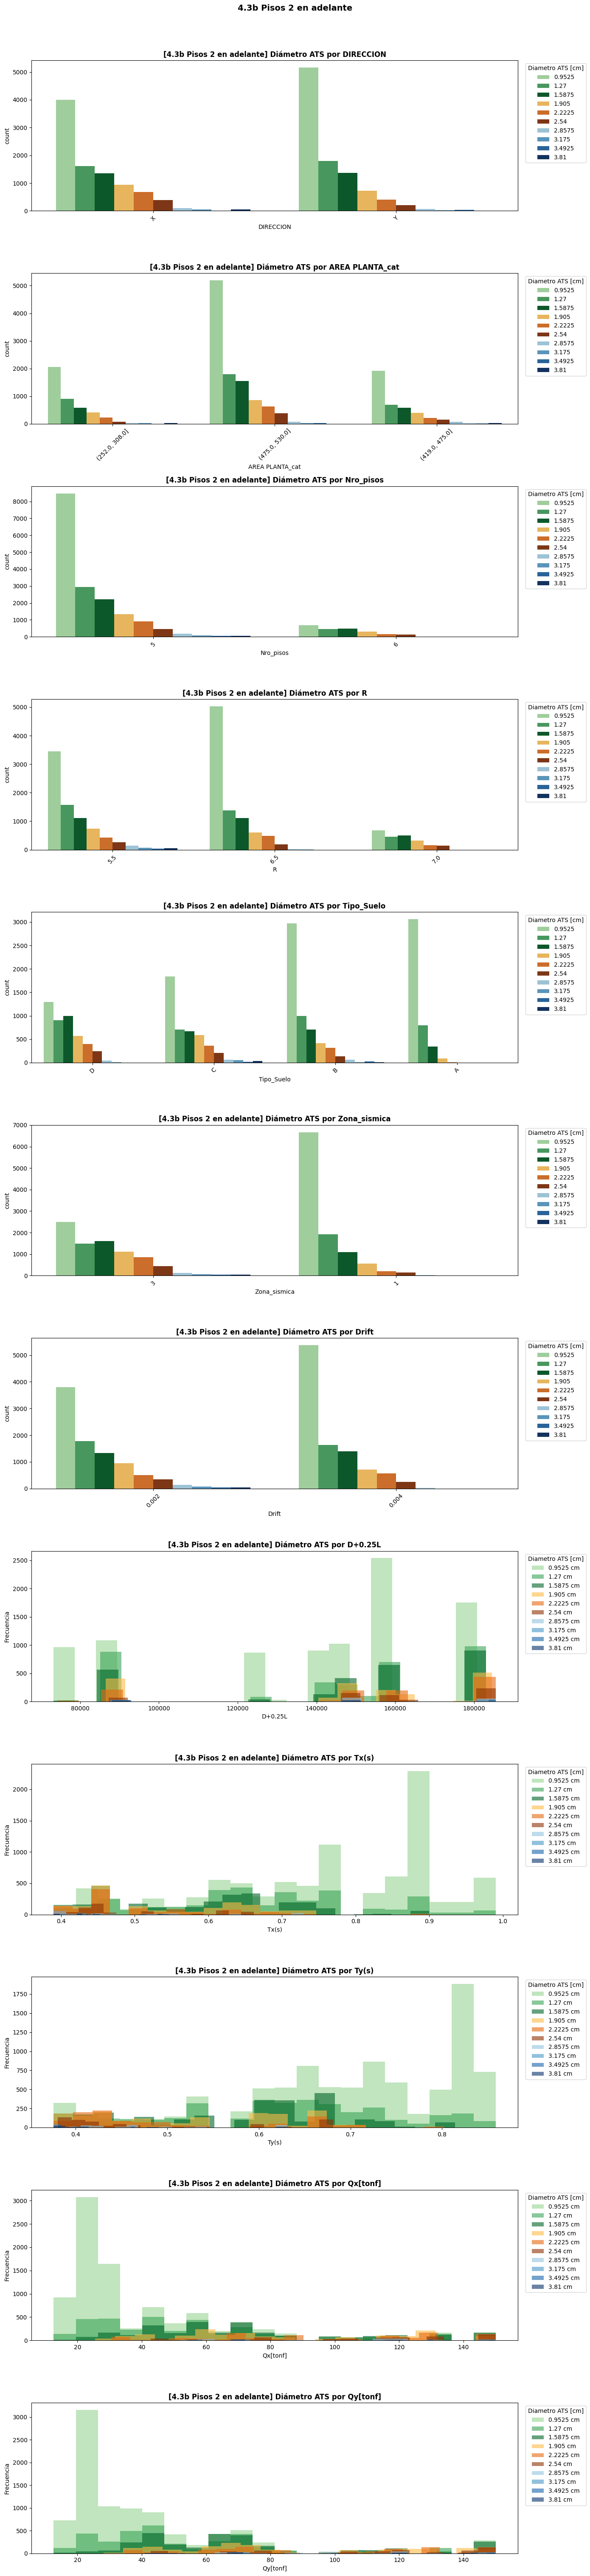

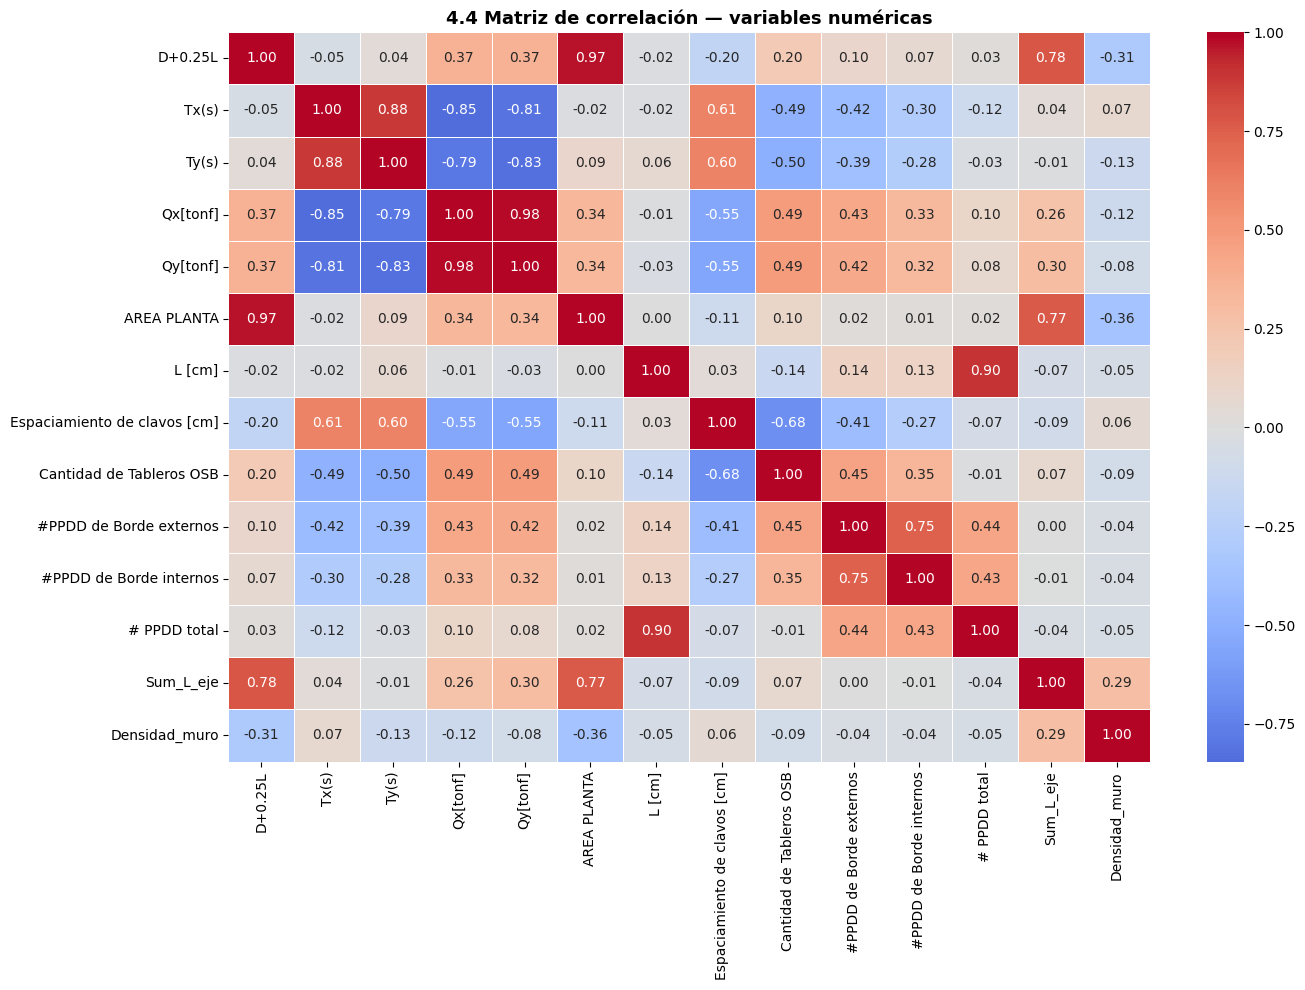

In [57]:
# ─────────────────────────────────────────────────────────────
# BLOQUE 4: EXPLORACIÓN VISUAL
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np

# Convertir a m² y categorizar para el area de planta (y que se se vea más legible en el gráfico)
df["AREA PLANTA_cat"] = pd.cut(
    df["AREA PLANTA"] / 10000,  # cm² a m²
    bins=5,
    precision=0
).astype(str)

# ── Preparación: orden y colores por diámetro ────────────────
df["Diametro ATS [cm]"] = df["Diametro ATS [cm]"].astype(float)
orden_diametros = sorted(df["Diametro ATS [cm]"].unique())
df["Diametro ATS [cm]"] = df["Diametro ATS [cm]"].astype(str)
orden_diametros = [str(d) for d in orden_diametros]

n      = len(orden_diametros)
tercio = n // 3

colores_diametros = {}
for j, diametro in enumerate(orden_diametros):
    if j < tercio:
        intensidad = 0.4 + (j / max(tercio - 1, 1)) * 0.5
        colores_diametros[diametro] = cm.Greens(intensidad)
    elif j < 2 * tercio:
        intensidad = 0.4 + ((j - tercio) / max(tercio - 1, 1)) * 0.5
        colores_diametros[diametro] = cm.YlOrBr(intensidad)
    else:
        intensidad = 0.4 + ((j - 2*tercio) / max(n - 2*tercio - 1, 1)) * 0.6
        colores_diametros[diametro] = cm.Blues(intensidad)

# ── 4.1 Desbalance de clases — Edificio completo ─────────────
# Muestra cuántos registros hay por cada diámetro ATS.
# El marcado desbalance entre clases frecuentes y minoritarias
# justifica el uso del modelo en cascada con especialista.

fig, ax = plt.subplots(figsize=(12, 5))
colores_lista = [colores_diametros[d] for d in orden_diametros]
conteos = [df[df["Diametro ATS [cm]"] == d].shape[0] for d in orden_diametros]

bars = ax.bar(orden_diametros, conteos, color=colores_lista, edgecolor="white")
ax.bar_label(bars, fmt="%d", padding=3, fontsize=9)
ax.set_xlabel("Diámetro ATS [cm]", fontsize=12)
ax.set_ylabel("Cantidad de registros", fontsize=12)
ax.set_title("4.1 Desbalance de clases — Diámetro ATS [cm] (Edificio completo)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Función reutilizable para graficar por subconjunto ────────
def graficar_diametros(dataframe, titulo):
    df_plot = dataframe.copy()
    df_plot["Diametro ATS [cm]"] = df_plot["Diametro ATS [cm]"].astype(float)
    orden_local = sorted(df_plot["Diametro ATS [cm]"].unique())
    df_plot["Diametro ATS [cm]"] = df_plot["Diametro ATS [cm]"].astype(str)
    orden_local = [str(d) for d in orden_local]

    n_loc       = len(orden_local)
    tercio_loc  = n_loc // 3
    colores_loc = {}
    for j, d in enumerate(orden_local):
        if j < tercio_loc:
            intensidad = 0.4 + (j / max(tercio_loc - 1, 1)) * 0.5
            colores_loc[d] = cm.Greens(intensidad)
        elif j < 2 * tercio_loc:
            intensidad = 0.4 + ((j - tercio_loc) / max(tercio_loc - 1, 1)) * 0.5
            colores_loc[d] = cm.YlOrBr(intensidad)
        else:
            intensidad = 0.4 + ((j - 2*tercio_loc) / max(n_loc - 2*tercio_loc - 1, 1)) * 0.6
            colores_loc[d] = cm.Blues(intensidad)

    categoricas = ["DIRECCION", "AREA PLANTA_cat", "Nro_pisos", "R",
                   "Tipo_Suelo", "Zona_sismica", "Drift"]
    continuas   = ["D+0.25L", "Tx(s)", "Ty(s)", "Qx[tonf]", "Qy[tonf]"]
    todas       = categoricas + continuas

    fig, axes = plt.subplots(len(todas), 1, figsize=(14, len(todas) * 5))

    for i, col in enumerate(todas):
        datos = df_plot[[col, "Diametro ATS [cm]"]].dropna()

        if col in continuas:
            for d in orden_local:
                subset = datos[datos["Diametro ATS [cm]"] == d][col]
                axes[i].hist(subset, alpha=0.6, label=f"{d} cm",
                             bins=20, color=colores_loc[d])
            axes[i].set_xlabel(col)
            axes[i].set_ylabel("Frecuencia")
            axes[i].legend(title="Diametro ATS [cm]",
                           bbox_to_anchor=(1.01, 1), loc="upper left")
        else:
            palette = {d: colores_loc[d] for d in orden_local}
            sns.countplot(data=datos, x=col, hue="Diametro ATS [cm]",
                          hue_order=orden_local, ax=axes[i], palette=palette)
            axes[i].tick_params(axis="x", rotation=45)
            axes[i].legend(title="Diametro ATS [cm]",
                           bbox_to_anchor=(1.01, 1), loc="upper left")

        axes[i].set_title(f"[{titulo}] Diámetro ATS por {col}",
                          fontsize=12, fontweight="bold")

    plt.suptitle(titulo, fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

# ── 4.2 Distribución por variable — Edificio completo ────────
# Permite identificar qué variables tienen mayor poder discriminativo
# para predecir el diámetro ATS considerando todos los registros.
graficar_diametros(df, "4.2 Edificio completo")

# ── 4.3 Distribución por variable — Piso 1 vs Pisos 2+ ───────
# La separación por nivel permite identificar si el comportamiento
# del diámetro ATS difiere entre el piso 1 (mayor carga acumulada)
# y los pisos superiores. Esta comparación motivó el entrenamiento
# de modelos separados, aunque el modelo final utilizado
# corresponde al del edificio completo.
df_piso1  = df[df["PISO"] == 1]
df_pisos2 = df[df["PISO"] != 1]

graficar_diametros(df_piso1,  "4.3a Piso 1")
graficar_diametros(df_pisos2, "4.3b Pisos 2 en adelante")

# ── 4.4 Matriz de correlación ─────────────────────────────────
# Muestra qué variables numéricas están más relacionadas entre sí.
# Útil para identificar variables redundantes o con alta correlación
# con la variable objetivo.
variables_corr = ["D+0.25L", "Tx(s)", "Ty(s)", "Qx[tonf]", "Qy[tonf]",
                  "AREA PLANTA", "L [cm]", "Espaciamiento de clavos [cm]",
                  "Cantidad de Tableros OSB", "#PPDD de Borde externos",
                  "#PPDD de Borde internos", "# PPDD total",
                  "Sum_L_eje", "Densidad_muro"]

corr = df[variables_corr].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("4.4 Matriz de correlación — variables numéricas",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [58]:
"""# ─────────────────────────────────────────────────────────────
# BLOQUE 5: DESCARGA DE GRÁFICOS (comentar antes de compartir)
# ─────────────────────────────────────────────────────────────
import zipfile
import os
from google.colab import files

graficos = [
    "4.1_desbalance_clases.png",
    "4.2_edificio_completo.png",
    "4.3a_piso1.png",
    "4.3b_pisos2.png",
    "4.4_matriz_correlacion.png"
]

with zipfile.ZipFile("graficos_exploracion.zip", "w") as zipf:
    for g in graficos:
        if os.path.exists(g):
            zipf.write(g)

files.download("graficos_exploracion.zip")
print("✓ Gráficos descargados en graficos_exploracion.zip")"""

'# ─────────────────────────────────────────────────────────────\n# BLOQUE 5: DESCARGA DE GRÁFICOS (comentar antes de compartir)\n# ─────────────────────────────────────────────────────────────\nimport zipfile\nimport os\nfrom google.colab import files\n\ngraficos = [\n    "4.1_desbalance_clases.png",\n    "4.2_edificio_completo.png",\n    "4.3a_piso1.png",\n    "4.3b_pisos2.png",\n    "4.4_matriz_correlacion.png"\n]\n\nwith zipfile.ZipFile("graficos_exploracion.zip", "w") as zipf:\n    for g in graficos:\n        if os.path.exists(g):\n            zipf.write(g)\n\nfiles.download("graficos_exploracion.zip")\nprint("✓ Gráficos descargados en graficos_exploracion.zip")'

PARTE 5) MODELOS DE PREDICCIÓN

5.1) MODELO DE REGRESIÓN PARA DENSIDAD DE MUROS

In [59]:
# ============================================================
# BLOQUE 6 — MODELADO PREDICTIVO
# ============================================================
# Este bloque desarrolla los dos modelos del MVP:
#   6.1 Modelo de regresión  → predice Sum_L_eje
#   6.2 Modelo de clasificación → predice Diámetro ATS [cm]
# ============================================================

# ---- 6.1 MODELO DE REGRESIÓN ----
# Variable objetivo: Sum_L_eje (suma del largo de muros por nivel y dirección)
# Esta variable permite calcular la densidad de muro del edificio.

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

variables_reg = [
    "DIRECCION", "D+0.25L", "Tx(s)", "Ty(s)", "Qx[tonf]", "Qy[tonf]",
    "AREA PLANTA", "Nro_pisos", "Drift", "R", "Tipo_Suelo", "Zona_sismica"
]
objetivo_reg = "Sum_L_eje"
categoricas_reg = ["DIRECCION", "Tipo_Suelo", "Zona_sismica"]

In [60]:
# Agrupar segun SUM_L_eje porque como el cálculo es por nivel se van a repetir los datos y va a sobre ajustar

df_agrupado = df.groupby(["DISENO", "PISO", "DIRECCION"], as_index=False).agg(
    **{col: (col, "first") for col in variables_reg if col not in ["DISENO", "PISO", "DIRECCION"]},
    Sum_L_eje=("Sum_L_eje", "first")
)

print(f"Filas originales      : {len(df)}")
print(f"Filas tras agrupar    : {len(df_agrupado)}")
print("→ Cada fila representa ahora un nivel-dirección único.")

Filas originales      : 23578
Filas tras agrupar    : 656
→ Cada fila representa ahora un nivel-dirección único.


In [61]:
print(df_agrupado.columns.tolist())

['DISENO', 'PISO', 'DIRECCION', 'D+0.25L', 'Tx(s)', 'Ty(s)', 'Qx[tonf]', 'Qy[tonf]', 'AREA PLANTA', 'Nro_pisos', 'Drift', 'R', 'Tipo_Suelo', 'Zona_sismica', 'Sum_L_eje']


In [62]:
# ---- Preparar datos ----
df_reg = df_agrupado[variables_reg + [objetivo_reg]].dropna().copy()

label_encoders_reg = {}
for col in categoricas_reg:
    le = LabelEncoder()
    df_reg[col] = le.fit_transform(df_reg[col].astype(str))
    label_encoders_reg[col] = le

X_reg = df_reg[variables_reg]
y_reg = df_reg[objetivo_reg]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Train: {X_train_r.shape[0]} filas | Test: {X_test_r.shape[0]} filas")

Train: 524 filas | Test: 132 filas


In [63]:
# ---- Comparar modelos ----
# Se incluye el Árbol de Decisión para mostrar explícitamente
# por qué se descarta (R²=1.00 es señal de memorización, no aprendizaje).

modelos_reg = {
    "Regresión Lineal":  LinearRegression(),
    "Ridge":             Ridge(),
    "Árbol de Decisión": DecisionTreeRegressor(random_state=42),
    "Random Forest":     RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
}

print("=" * 55)
print(f"{'Modelo':<25} {'R²':>8} {'MAE (cm)':>12}")
print("=" * 55)

resultados_reg = {}
for nombre, modelo in modelos_reg.items():
    modelo.fit(X_train_r, y_train_r)
    pred      = modelo.predict(X_test_r)
    r2        = r2_score(y_test_r, pred)
    mae       = mean_absolute_error(y_test_r, pred)
    resultados_reg[nombre] = {"modelo": modelo, "r2": r2, "mae": mae}
    print(f"{nombre:<25} {r2:>8.4f} {mae:>12.2f}")

print("=" * 55)
print("\n  Árbol de Decisión: R²=1.00 y MAE=0.00 → descartado.")

Modelo                          R²     MAE (cm)
Regresión Lineal            0.8429      1081.16
Ridge                       0.8380      1151.30
Árbol de Decisión           1.0000         0.00
Random Forest               0.9991        13.67
Gradient Boosting           0.9996        25.35

  Árbol de Decisión: R²=1.00 y MAE=0.00 → descartado.


In [64]:
# ---- Verificar overfitting en RF y GB ----

for nombre in ["Random Forest", "Gradient Boosting"]:
    modelo     = resultados_reg[nombre]["modelo"]
    pred_train = modelo.predict(X_train_r)
    pred_test  = modelo.predict(X_test_r)
    r2_train   = r2_score(y_train_r, pred_train)
    r2_test    = r2_score(y_test_r, pred_test)
    diff       = abs(r2_train - r2_test)
    flag       = "  posible overfit" if diff > 0.05 else "✅ ok"

    print(f"\n{nombre}")
    print(f"  R² train     : {r2_train:.4f}")
    print(f"  R² test      : {r2_test:.4f}")
    print(f"  Diferencia   : {diff:.4f}  {flag}")

# ---- Modelo seleccionado ----
rf_reg = resultados_reg["Random Forest"]["modelo"]
print("\n" + "=" * 55)
print(" Modelo seleccionado: Random Forest")
print(f"   R²  : {resultados_reg['Random Forest']['r2']:.4f}")
print(f"   MAE : {resultados_reg['Random Forest']['mae']:.2f} cm")
print("=" * 55)


Random Forest
  R² train     : 0.9992
  R² test      : 0.9991
  Diferencia   : 0.0001  ✅ ok

Gradient Boosting
  R² train     : 0.9999
  R² test      : 0.9996
  Diferencia   : 0.0003  ✅ ok

 Modelo seleccionado: Random Forest
   R²  : 0.9991
   MAE : 13.67 cm


In [65]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_reg, X_reg, y_reg, cv=5, scoring="r2")
print(f"R² promedio K-Fold (5): {scores.mean():.4f} ± {scores.std():.4f}")

R² promedio K-Fold (5): 0.8709 ± 0.2549


In [66]:
from sklearn.model_selection import GroupKFold, cross_val_score
import numpy as np

# ---- GroupKFold: cada edificio (DISENO) va completo a train o test ----
# Nunca mezcla filas del mismo edificio entre folds

gkf = GroupKFold(n_splits=5)
grupos = df_agrupado["DISENO"]  # variable que identifica cada edificio

scores_gkf = cross_val_score(
    rf_reg, X_reg, y_reg,
    cv=gkf,
    groups=grupos,
    scoring="r2"
)

print("GroupKFold (5 folds) — agrupado por edificio:")
print("=" * 45)
for i, s in enumerate(scores_gkf, 1):
    print(f"  Fold {i}: R² = {s:.4f}")
print("=" * 45)
print(f"  Promedio : {scores_gkf.mean():.4f}")
print(f"  Std      : {scores_gkf.std():.4f}")

GroupKFold (5 folds) — agrupado por edificio:
  Fold 1: R² = 1.0000
  Fold 2: R² = 0.9980
  Fold 3: R² = 0.9972
  Fold 4: R² = 0.9999
  Fold 5: R² = 0.9999
  Promedio : 0.9990
  Std      : 0.0012


✅ Modelo seleccionado: Random Forest
   R²  : 0.9991
   MAE : 13.67 cm


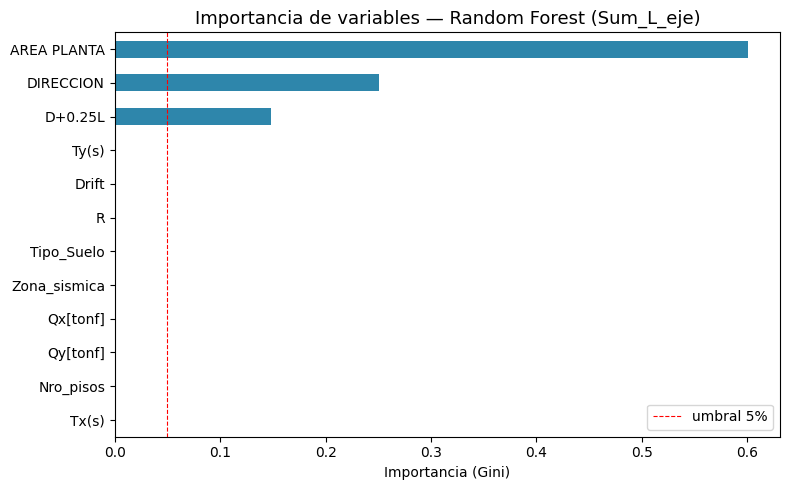

In [67]:
# ---- Modelo final ----
rf_reg = resultados_reg["Random Forest"]["modelo"]
print("✅ Modelo seleccionado: Random Forest")
print(f"   R²  : {resultados_reg['Random Forest']['r2']:.4f}")
print(f"   MAE : {resultados_reg['Random Forest']['mae']:.2f} cm")

# ---- Importancia de variables (análisis complementario) ----
importancias = pd.Series(
    rf_reg.feature_importances_,
    index=variables_reg
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot(kind="barh", ax=ax, color="#2E86AB")
ax.set_title("Importancia de variables — Random Forest (Sum_L_eje)", fontsize=13)
ax.set_xlabel("Importancia (Gini)")
ax.axvline(x=0.05, color="red", linestyle="--", linewidth=0.8, label="umbral 5%")
ax.legend()
plt.tight_layout()
plt.show()

5.2) MODELO DE CALSIFICACIÓN DE DIÁMETRO ATS

In [68]:
# ============================================================
# BLOQUE 6.2 — MODELO DE CLASIFICACIÓN: DIÁMETRO ATS
# ============================================================


from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTENC
from xgboost import XGBClassifier
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Variables ----
variables_clf = [
    "DIRECCION", "D+0.25L", "Tx(s)", "Ty(s)", "Qx[tonf]", "Qy[tonf]",
    "AREA PLANTA", "Nro_pisos", "Drift", "R", "Tipo_Suelo", "Zona_sismica",
    "Densidad_muro"
]
objetivo_clf    = "Diametro ATS [cm]"
categoricas_clf = ["DIRECCION", "Tipo_Suelo", "Zona_sismica"]

# Diámetros comerciales disponibles
VALORES_COMERCIALES = np.array([
    0.9525, 1.27, 1.5875, 1.905, 2.2225,
    2.54, 2.8575, 3.175, 3.4925, 3.81, 4.445
])

# Diámetros minoritarios → los maneja el especialista en cascada
DIAMETROS_DIFICILES = ['2.8575', '3.175', '3.4925', '3.81', '4.445']

In [69]:
# ---- Preparar datos ----
df_clf = df[variables_clf + [objetivo_clf]].dropna().copy()

label_encoders_clf = {}
for col in categoricas_clf:
    le = LabelEncoder()
    df_clf[col] = le.fit_transform(df_clf[col].astype(str))
    label_encoders_clf[col] = le

X_clf    = df_clf[variables_clf]
y_clf    = df_clf[objetivo_clf].astype(str)
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y_clf)

print("Clases:", le_target.classes_)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ---- Comparar modelos ----
# Nota: RF incluye class_weight='balanced' desde el inicio
# porque el desbalance es evidente desde la exploración.
# El Árbol se incluye para mostrar por qué se descarta.
modelos_clf = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Árbol de Decisión":   DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42,
                                                   class_weight="balanced"),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, random_state=42),
}

print("\n" + "=" * 55)
print(f"{'Modelo':<25} {'Accuracy':>10} {'Overfit':>10}")
print("=" * 55)

resultados_clf = {}
for nombre, modelo in modelos_clf.items():
    modelo.fit(X_train_c, y_train_c)
    acc_train = accuracy_score(y_train_c, modelo.predict(X_train_c))
    acc_test  = accuracy_score(y_test_c,  modelo.predict(X_test_c))
    diff      = abs(acc_train - acc_test)
    flag      = "⚠️" if diff > 0.05 else "✅"
    resultados_clf[nombre] = {"modelo": modelo, "accuracy": acc_test}
    print(f"{nombre:<25} {acc_test:>10.2%} {diff:>8.2%} {flag}")

print("=" * 55)

# ---- Justificación de selección ----
# Árbol de Decisión: accuracy similar a RF pero sin robustez
# → memoriza patrones específicos, más sensible a variaciones
# → RF promedia 200 árboles → más estable y generalizable
# → Se selecciona Random Forest como modelo base

rf_clf = resultados_clf["Random Forest"]["modelo"]
print("\n✅ Modelo base seleccionado: Random Forest")
print(f"   Accuracy: {resultados_clf['Random Forest']['accuracy']:.2%}")
print("   Motivo: mayor robustez estructural sobre el Árbol de Decisión")
print("           (accuracy similar pero generalización más confiable)")

Clases: ['0.9525' '1.27' '1.5875' '1.905' '2.2225' '2.54' '2.8575' '3.175'
 '3.4925' '3.81' '4.445']

Modelo                      Accuracy    Overfit


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Regresión Logística           38.89%    0.81% ✅
Árbol de Decisión             85.69%    0.94% ✅
Random Forest                 84.44%    0.14% ✅
Gradient Boosting             84.08%    0.86% ✅

✅ Modelo base seleccionado: Random Forest
   Accuracy: 84.44%
   Motivo: mayor robustez estructural sobre el Árbol de Decisión
           (accuracy similar pero generalización más confiable)


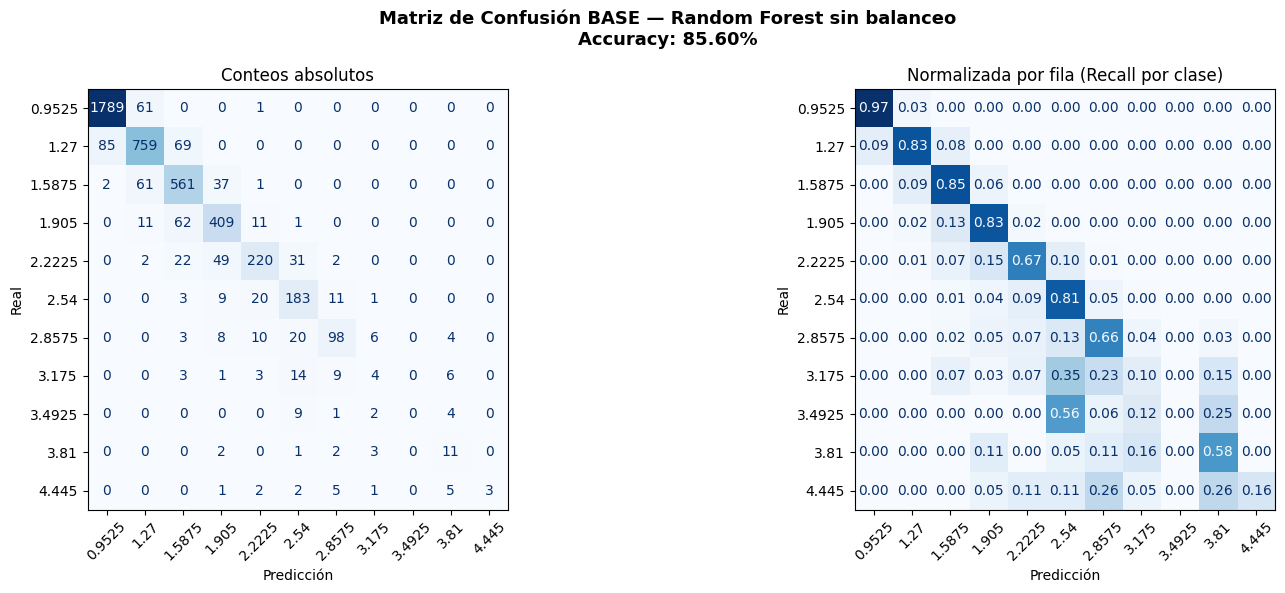


Accuracy base: 85.60%
REPORTE BASE — RF sin estrategias de balanceo
              precision    recall  f1-score   support

      0.9525       0.95      0.97      0.96      1851
        1.27       0.85      0.83      0.84       913
      1.5875       0.78      0.85      0.81       662
       1.905       0.79      0.83      0.81       494
      2.2225       0.82      0.67      0.74       326
        2.54       0.70      0.81      0.75       227
      2.8575       0.77      0.66      0.71       149
       3.175       0.24      0.10      0.14        40
      3.4925       0.00      0.00      0.00        16
        3.81       0.37      0.58      0.45        19
       4.445       1.00      0.16      0.27        19

    accuracy                           0.86      4716
   macro avg       0.66      0.59      0.59      4716
weighted avg       0.85      0.86      0.85      4716


⚠️  Notar el bajo recall en diámetros ≥ 2.8575 cm
   → justifica la necesidad de estrategias de balanceo


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [70]:
# ============================================================
# MATRIZ DE CONFUSIÓN BASE — Random Forest sin estrategias
# Sirve como referencia para justificar las mejoras posteriores
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# ---- Preparar datos ----
df_base = df[variables_clf + [objetivo_clf]].dropna().copy()

le_enc_base = {}
for col in categoricas_clf:
    le = LabelEncoder()
    df_base[col] = le.fit_transform(df_base[col].astype(str))
    le_enc_base[col] = le

X_base = df_base[variables_clf]
y_base = df_base[objetivo_clf].astype(str)

le_base = LabelEncoder()
y_base_enc = le_base.fit_transform(y_base)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_base, y_base_enc, test_size=0.2, random_state=42, stratify=y_base_enc
)

# ---- Modelo base: RF sin ninguna estrategia de balanceo ----
clf_base = RandomForestClassifier(n_estimators=200, random_state=42)
clf_base.fit(X_train_b, y_train_b)
pred_base = clf_base.predict(X_test_b)

acc_base = accuracy_score(y_test_b, pred_base)
clases   = le_base.classes_

# ---- Matrices de confusión ----
cm_abs  = confusion_matrix(y_test_b, pred_base)
cm_norm = confusion_matrix(y_test_b, pred_base, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f"Matriz de Confusión BASE — Random Forest sin balanceo\nAccuracy: {acc_base:.2%}",
    fontsize=13, fontweight='bold'
)

ConfusionMatrixDisplay(cm_abs, display_labels=clases).plot(
    ax=axes[0], colorbar=False, cmap='Blues', values_format='d'
)
axes[0].set_title("Conteos absolutos")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")
axes[0].tick_params(axis='x', rotation=45)

ConfusionMatrixDisplay(cm_norm, display_labels=clases).plot(
    ax=axes[1], colorbar=False, cmap='Blues', values_format='.2f'
)
axes[1].set_title("Normalizada por fila (Recall por clase)")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("cm_base_rf_sin_balanceo.png", dpi=150, bbox_inches='tight')
plt.show()

# ---- Reporte detallado ----
print(f"\nAccuracy base: {acc_base:.2%}")
print("=" * 60)
print("REPORTE BASE — RF sin estrategias de balanceo")
print("=" * 60)
print(classification_report(y_test_b, pred_base, target_names=clases))
print("\n⚠️  Notar el bajo recall en diámetros ≥ 2.8575 cm")
print("   → justifica la necesidad de estrategias de balanceo")

In [71]:
# ---- Distribución de clases ----
print("Distribución de Diámetro ATS [cm]:")
print("=" * 45)
dist = df[objetivo_clf].value_counts().sort_index()
total = len(df)
for val, cnt in dist.items():
    barra = "█" * int(cnt / total * 50)
    print(f"  {val:>7} cm → {cnt:>5} ({cnt/total:.1%})  {barra}")

# ---- ¿Por qué separar por piso? ----
# El piso 1 concentra los diámetros grandes (cargas acumuladas)
# mientras que pisos superiores dominan los diámetros pequeños.
# Entrenar un solo modelo mezcla estas distribuciones distintas.

df["grupo_piso"] = df["PISO"].apply(lambda x: "Piso 1" if x == 1 else "Pisos 2+")

print("\nDistribución por grupo de piso:")
print("=" * 60)
tabla = df.groupby(["grupo_piso", objetivo_clf]).size().unstack(fill_value=0)
print(tabla.to_string())
print("\nTotal por grupo:")
print(df["grupo_piso"].value_counts().to_string())

# ---- Separar datasets ----
df_piso1  = df[df["PISO"] == 1].copy()
df_pisos2 = df[df["PISO"] != 1].copy()
print(f"\nPiso 1  : {len(df_piso1):,} registros")
print(f"Pisos 2+: {len(df_pisos2):,} registros")

Distribución de Diámetro ATS [cm]:
   0.9525 cm →  9256 (39.3%)  ███████████████████
     1.27 cm →  4566 (19.4%)  █████████
   1.5875 cm →  3308 (14.0%)  ███████
    1.905 cm →  2467 (10.5%)  █████
   2.2225 cm →  1628 (6.9%)  ███
     2.54 cm →  1135 (4.8%)  ██
   2.8575 cm →   747 (3.2%)  █
    3.175 cm →   199 (0.8%)  
   3.4925 cm →    82 (0.3%)  
     3.81 cm →    93 (0.4%)  
    4.445 cm →    97 (0.4%)  

Distribución por grupo de piso:
Diametro ATS [cm]  0.9525  1.27  1.5875  1.905  2.2225  2.54  2.8575  3.175  3.4925  3.81  4.445
grupo_piso                                                                                      
Piso 1                 91  1164     591    802     552   544     577    126      38    44     97
Pisos 2+             9165  3402    2717   1665    1076   591     170     73      44    49      0

Total por grupo:
grupo_piso
Pisos 2+    18952
Piso 1       4626

Piso 1  : 4,626 registros
Pisos 2+: 18,952 registros


In [72]:
# ============================================================
# NOTA: Esta sección documenta todas las estrategias probadas.

# ============================================================

# ---- Función auxiliar base ----
def preparar_datos_clf(dataframe):
    df_temp = dataframe[variables_clf + [objetivo_clf]].dropna().copy()
    le_enc = {}
    for col in categoricas_clf:
        le = LabelEncoder()
        df_temp[col] = le.fit_transform(df_temp[col].astype(str))
        le_enc[col] = le
    X = df_temp[variables_clf]
    y = df_temp[objetivo_clf].astype(str)
    le_t = LabelEncoder()
    y_enc = le_t.fit_transform(y)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
    )
    return X_train, X_test, y_train, y_test, le_t, le_enc

# ================================================================
# ESTRATEGIA A — class_weight='balanced'
# Asigna mayor peso a clases minoritarias sin generar muestras nuevas.
# ================================================================
def estrategia_balanced(dataframe, nombre):
    X_train, X_test, y_train, y_test, le_t, _ = preparar_datos_clf(dataframe)
    clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"  [balanced] {nombre}: {acc:.2%}")
    return acc

print("ESTRATEGIA A — class_weight='balanced'")
acc_a_completo = estrategia_balanced(df,        "Edificio completo")
acc_a_piso1    = estrategia_balanced(df_piso1,  "Piso 1")
acc_a_pisos2   = estrategia_balanced(df_pisos2, "Pisos 2+")

# ================================================================
# ESTRATEGIA B — SMOTE-NC
# Genera muestras sintéticas respetando variables categóricas.
# Más apropiado que SMOTE estándar porque el dataset tiene
# variables categóricas (DIRECCION, Tipo_Suelo, Zona_sismica).
# ================================================================
cat_indices = [variables_clf.index(col) for col in categoricas_clf]

def estrategia_smotenc(dataframe, nombre):
    X_train, X_test, y_train, y_test, le_t, _ = preparar_datos_clf(dataframe)

    max_count     = max(Counter(y_train).values())
    sampling_dict = {
        clase: max(count, int(max_count * 0.5))
        for clase, count in Counter(y_train).items()
    }
    smote_nc = SMOTENC(categorical_features=cat_indices,
                       sampling_strategy=sampling_dict,
                       k_neighbors=3, random_state=42)
    X_res, y_res = smote_nc.fit_resample(X_train, y_train)

    print(f"\n  Distribución tras SMOTE-NC ({nombre}):")
    for cls, cnt in sorted(Counter(y_res).items()):
        print(f"    {le_t.classes_[cls]} cm → {cnt} muestras")

    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_res, y_res)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"  [SMOTE-NC] {nombre}: {acc:.2%}")
    return acc

print("\nESTRATEGIA B — SMOTE-NC")
acc_b_completo = estrategia_smotenc(df,        "Edificio completo")
acc_b_piso1    = estrategia_smotenc(df_piso1,  "Piso 1")
acc_b_pisos2   = estrategia_smotenc(df_pisos2, "Pisos 2+")

# ================================================================
# ESTRATEGIA C — Regresión directa con ajuste a valor comercial
# Trata el diámetro como variable continua y redondea al comercial
# más cercano. No requiere balanceo explícito.
# ================================================================
def ajustar_a_comercial(preds):
    return np.array([
        VALORES_COMERCIALES[np.argmin(np.abs(VALORES_COMERCIALES - p))]
        for p in preds
    ])

def estrategia_regresion(dataframe, nombre):
    X_train, X_test, y_train, y_test, le_t, _ = preparar_datos_clf(dataframe)
    # Convertir target codificado a valor numérico original
    y_train_num = np.array([float(le_t.classes_[i]) for i in y_train])
    y_test_num  = np.array([float(le_t.classes_[i]) for i in y_test])

    reg = RandomForestRegressor(n_estimators=200, random_state=42)
    reg.fit(X_train, y_train_num)
    pred = ajustar_a_comercial(reg.predict(X_test))
    y_aj = ajustar_a_comercial(y_test_num)
    acc  = np.mean(pred == y_aj)
    print(f"  [regresión] {nombre}: {acc:.2%}")
    return acc

print("\nESTRATEGIA C — Regresión directa")
acc_c_completo = estrategia_regresion(df,        "Edificio completo")
acc_c_piso1    = estrategia_regresion(df_piso1,  "Piso 1")
acc_c_pisos2   = estrategia_regresion(df_pisos2, "Pisos 2+")

# ================================================================
# ESTRATEGIA D — Regresión en escala logarítmica
# log(y) comprime la escala → reduce el efecto de outliers en
# los extremos de la distribución de diámetros.
# ================================================================
def estrategia_regresion_log(dataframe, nombre):
    X_train, X_test, y_train, y_test, le_t, _ = preparar_datos_clf(dataframe)
    y_train_num = np.array([float(le_t.classes_[i]) for i in y_train])
    y_test_num  = np.array([float(le_t.classes_[i]) for i in y_test])

    reg = RandomForestRegressor(n_estimators=200, random_state=42)
    reg.fit(X_train, np.log(y_train_num))
    pred = ajustar_a_comercial(np.exp(reg.predict(X_test)))
    y_aj = ajustar_a_comercial(y_test_num)
    acc  = np.mean(pred == y_aj)
    print(f"  [log] {nombre}: {acc:.2%}")
    return acc

print("\nESTRATEGIA D — Regresión logarítmica")
acc_d_completo = estrategia_regresion_log(df,        "Edificio completo")
acc_d_piso1    = estrategia_regresion_log(df_piso1,  "Piso 1")
acc_d_pisos2   = estrategia_regresion_log(df_pisos2, "Pisos 2+")

# ================================================================
# ESTRATEGIA E — XGBoost con sample weights
# ================================================================
def estrategia_xgboost(dataframe, nombre):
    X_train, X_test, y_train, y_test, le_t, _ = preparar_datos_clf(dataframe)

    # Limpiar nombres de columnas para XGBoost (no acepta [ ] < >)
    cols_limpias = [c.replace('[','').replace(']','').replace('<','').replace('>','')
                    for c in variables_clf]
    X_train.columns = cols_limpias
    X_test.columns  = cols_limpias

    sw = compute_sample_weight('balanced', y_train)
    clf = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                        eval_metric='mlogloss', random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train, sample_weight=sw)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"  [XGBoost] {nombre}: {acc:.2%}")
    return acc

print("\nESTRATEGIA E — XGBoost balanced")
acc_e_completo = estrategia_xgboost(df,        "Edificio completo")
acc_e_piso1    = estrategia_xgboost(df_piso1,  "Piso 1")
acc_e_pisos2   = estrategia_xgboost(df_pisos2, "Pisos 2+")

# ================================================================
# ESTRATEGIA F — SMOTE-NC + XGBoost
# ================================================================
def estrategia_smotenc_xgb(dataframe, nombre):
    X_train, X_test, y_train, y_test, le_t, _ = preparar_datos_clf(dataframe)

    cols_limpias = [c.replace('[','').replace(']','').replace('<','').replace('>','')
                    for c in variables_clf]
    X_train.columns = cols_limpias
    X_test.columns  = cols_limpias
    cat_idx_limpios = [cols_limpias.index(
        c.replace('[','').replace(']','').replace('<','').replace('>',''))
        for c in categoricas_clf]

    smote_nc = SMOTENC(categorical_features=cat_idx_limpios,
                       k_neighbors=3, random_state=42)
    X_res, y_res = smote_nc.fit_resample(X_train, y_train)

    clf = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                        eval_metric='mlogloss', random_state=42, n_jobs=-1)
    clf.fit(X_res, y_res)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"  [SMOTE-NC+XGB] {nombre}: {acc:.2%}")
    return acc

print("\nESTRATEGIA F — SMOTE-NC + XGBoost")
acc_f_completo = estrategia_smotenc_xgb(df,        "Edificio completo")
acc_f_piso1    = estrategia_smotenc_xgb(df_piso1,  "Piso 1")
acc_f_pisos2   = estrategia_smotenc_xgb(df_pisos2, "Pisos 2+")

# ================================================================
# ESTRATEGIA G — Balanced Random Forest tuneado
# ================================================================
from imblearn.ensemble import BalancedRandomForestClassifier

def estrategia_brf(dataframe, nombre):
    X_train, X_test, y_train, y_test, le_t, _ = preparar_datos_clf(dataframe)
    clf = BalancedRandomForestClassifier(
        n_estimators=500, max_depth=None, min_samples_leaf=1,
        sampling_strategy='not majority', replacement=False,
        class_weight='balanced_subsample', random_state=42, n_jobs=-1
    )
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"  [BRF] {nombre}: {acc:.2%}")
    return acc

print("\nESTRATEGIA G — Balanced Random Forest")
acc_g_completo = estrategia_brf(df,        "Edificio completo")
acc_g_piso1    = estrategia_brf(df_piso1,  "Piso 1")
acc_g_pisos2   = estrategia_brf(df_pisos2, "Pisos 2+")

ESTRATEGIA A — class_weight='balanced'
  [balanced] Edificio completo: 84.44%
  [balanced] Piso 1: 79.48%
  [balanced] Pisos 2+: 86.68%

ESTRATEGIA B — SMOTE-NC

  Distribución tras SMOTE-NC (Edificio completo):
    0.9525 cm → 7405 muestras
    1.27 cm → 3702 muestras
    1.5875 cm → 3702 muestras
    1.905 cm → 3702 muestras
    2.2225 cm → 3702 muestras
    2.54 cm → 3702 muestras
    2.8575 cm → 3702 muestras
    3.175 cm → 3702 muestras
    3.4925 cm → 3702 muestras
    3.81 cm → 3702 muestras
    4.445 cm → 3702 muestras
  [SMOTE-NC] Edificio completo: 84.52%

  Distribución tras SMOTE-NC (Piso 1):
    0.9525 cm → 465 muestras
    1.27 cm → 931 muestras
    1.5875 cm → 473 muestras
    1.905 cm → 641 muestras
    2.2225 cm → 465 muestras
    2.54 cm → 465 muestras
    2.8575 cm → 465 muestras
    3.175 cm → 465 muestras
    3.4925 cm → 465 muestras
    3.81 cm → 465 muestras
    4.445 cm → 465 muestras
  [SMOTE-NC] Piso 1: 79.16%

  Distribución tras SMOTE-NC (Pisos 2+):
    0.95

In [73]:
# ============================================================
# TABLA RESUMEN — todas las estrategias exploradas
# ============================================================
resumen = {
    "A — RF balanced":       [acc_a_completo, acc_a_piso1, acc_a_pisos2],
    "B — RF + SMOTE-NC":     [acc_b_completo, acc_b_piso1, acc_b_pisos2],
    "C — Regresión directa": [acc_c_completo, acc_c_piso1, acc_c_pisos2],
    "D — Regresión log":     [acc_d_completo, acc_d_piso1, acc_d_pisos2],
    "E — XGBoost balanced":  [acc_e_completo, acc_e_piso1, acc_e_pisos2],
    "F — SMOTE-NC + XGBoost":[acc_f_completo, acc_f_piso1, acc_f_pisos2],
    "G — BRF tuneado":       [acc_g_completo, acc_g_piso1, acc_g_pisos2],
    "H — Cascada ✅":        [0.8564,         0.8045,      0.8700],
}

df_resumen = pd.DataFrame(resumen,
    index=["Edificio completo", "Piso 1", "Pisos 2+"]).T

print("\nRESUMEN DE ESTRATEGIAS EXPLORADAS")
print("=" * 65)
print(df_resumen.to_string(float_format="{:.2%}".format))
print("=" * 65)
print("\n✅ Cascada seleccionada: mejor accuracy en los 3 grupos")
print("   + interpretabilidad estructural del proceso de decisión")


RESUMEN DE ESTRATEGIAS EXPLORADAS
                        Edificio completo  Piso 1  Pisos 2+
A — RF balanced                    84.44%  79.48%    86.68%
B — RF + SMOTE-NC                  84.52%  79.16%    86.73%
C — Regresión directa              83.14%  78.08%    85.99%
D — Regresión log                  83.82%  78.29%    86.39%
E — XGBoost balanced               84.44%  77.32%    86.73%
F — SMOTE-NC + XGBoost             83.55%  79.16%    86.60%
G — BRF tuneado                    76.46%  75.05%    74.31%
H — Cascada ✅                      85.64%  80.45%    87.00%

✅ Cascada seleccionada: mejor accuracy en los 3 grupos
   + interpretabilidad estructural del proceso de decisión



████████████████████████████████████████████████████████████
   MODELO FINAL — CASCADA
████████████████████████████████████████████████████████████

  Muestras para el especialista (MODELO EDIFICIO COMPLETO):
Diametro ATS [cm]
2.8575    598
3.175     159
3.4925     66
3.81       74
4.445      78

   MODELO EDIFICIO COMPLETO — Cascada (general + especialista)
  Casos enviados al especialista : 178 (3.8%)
  Accuracy total                 : 85.39%

  ──────────────────────────────────────────────────
  ⚠️  ADVERTENCIA DE CONFIABILIDAD (F1 ≤ 0.65)
  ──────────────────────────────────────────────────
  Los siguientes diámetros predichos tienen
  F1-score bajo en el grupo 'MODELO EDIFICIO COMPLETO':
    → 2.8575 cm
    → 3.175 cm
    → 3.4925 cm
    → 3.81 cm
    → 4.445 cm
  Casos afectados : 178 de 4716 (3.8%)
  Recomendación   : validar estos casos con el método STTP.
  ──────────────────────────────────────────────────


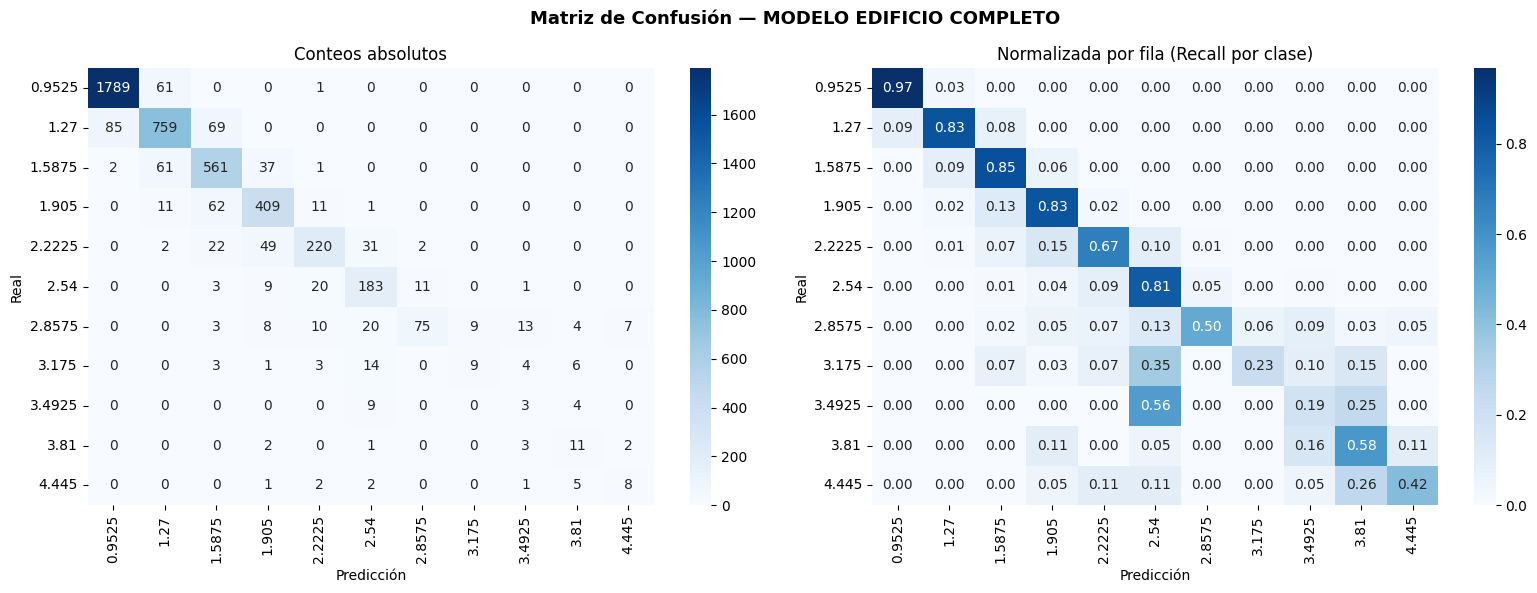

              precision    recall  f1-score   support

      0.9525       0.95      0.97      0.96      1851
        1.27       0.85      0.83      0.84       913
      1.5875       0.78      0.85      0.81       662
       1.905       0.79      0.83      0.81       494
      2.2225       0.82      0.67      0.74       326
        2.54       0.70      0.81      0.75       227
      2.8575       0.85      0.50      0.63       149
       3.175       0.50      0.23      0.31        40
      3.4925       0.12      0.19      0.15        16
        3.81       0.37      0.58      0.45        19
       4.445       0.47      0.42      0.44        19

    accuracy                           0.85      4716
   macro avg       0.65      0.62      0.63      4716
weighted avg       0.86      0.85      0.85      4716


  Muestras para el especialista (MODELO PISO 1):
Diametro ATS [cm]
2.8575    461
3.175     101
3.4925     30
3.81       35
4.445      78

   MODELO PISO 1 — Cascada (general + especialis

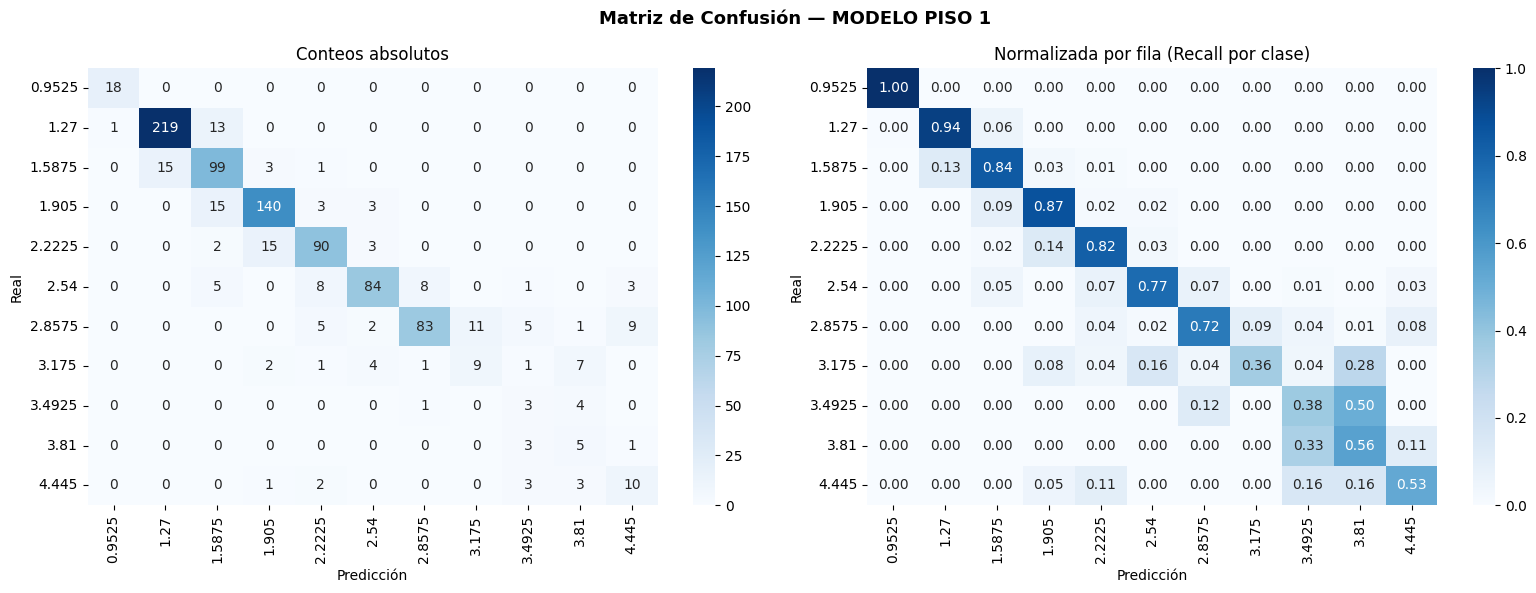

              precision    recall  f1-score   support

      0.9525       0.95      1.00      0.97        18
        1.27       0.94      0.94      0.94       233
      1.5875       0.74      0.84      0.79       118
       1.905       0.87      0.87      0.87       161
      2.2225       0.82      0.82      0.82       110
        2.54       0.88      0.77      0.82       109
      2.8575       0.89      0.72      0.79       116
       3.175       0.45      0.36      0.40        25
      3.4925       0.19      0.38      0.25         8
        3.81       0.25      0.56      0.34         9
       4.445       0.43      0.53      0.48        19

    accuracy                           0.82       926
   macro avg       0.67      0.71      0.68       926
weighted avg       0.84      0.82      0.83       926


  Muestras para el especialista (MODELO PISOS 2+):
Diametro ATS [cm]
2.8575    136
3.175      58
3.4925     35
3.81       39

   MODELO PISOS 2+ — Cascada (general + especialista)
  Caso

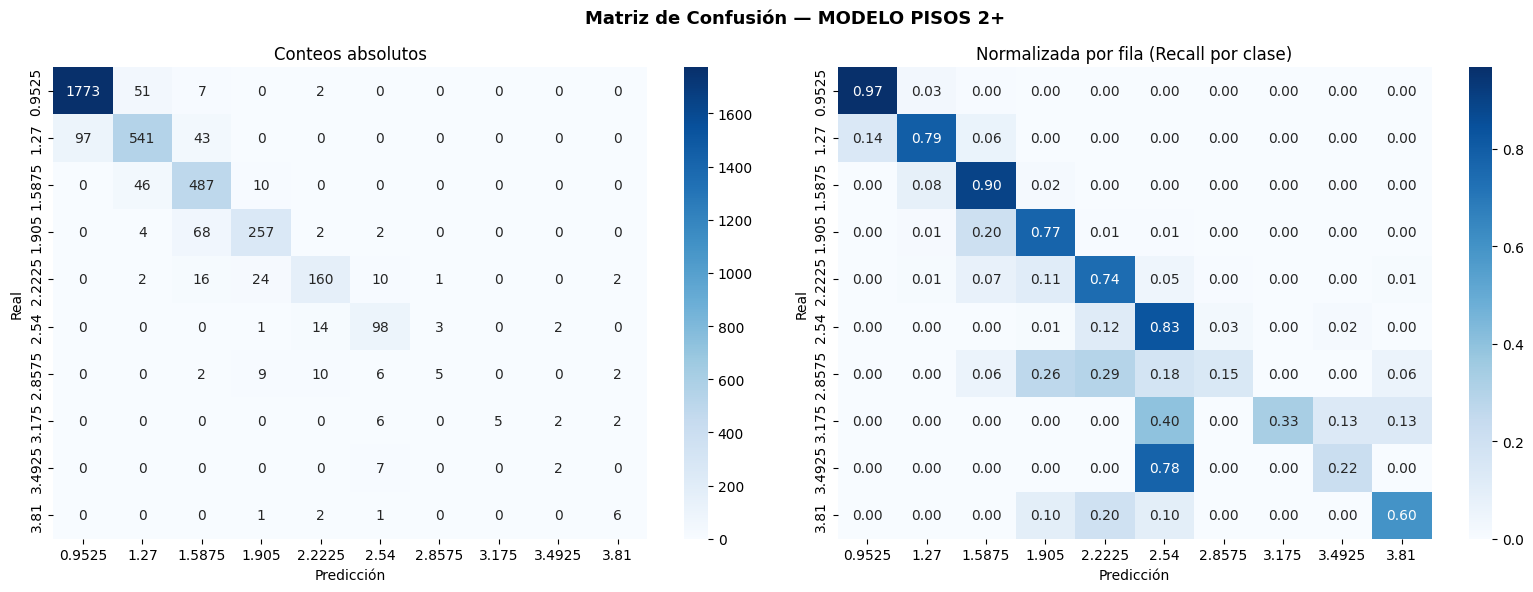

              precision    recall  f1-score   support

      0.9525       0.95      0.97      0.96      1833
        1.27       0.84      0.79      0.82       681
      1.5875       0.78      0.90      0.84       543
       1.905       0.85      0.77      0.81       333
      2.2225       0.84      0.74      0.79       215
        2.54       0.75      0.83      0.79       118
      2.8575       0.56      0.15      0.23        34
       3.175       1.00      0.33      0.50        15
      3.4925       0.33      0.22      0.27         9
        3.81       0.50      0.60      0.55        10

    accuracy                           0.88      3791
   macro avg       0.74      0.63      0.65      3791
weighted avg       0.88      0.88      0.88      3791



In [74]:
# ============================================================
# MODELO EN CASCADA — con advertencia de confiabilidad
# ── Lógica:
#    1. Modelo general → predice todos los diámetros
#    2. Si predice un diámetro difícil (≥2.8575) → pasa al
#       modelo especialista entrenado solo en esas clases
#    3. El especialista refina la predicción entre los 5
#       diámetros minoritarios
#    4. Si el diámetro predicho tiene F1 ≤ 0.65 → advertencia
# ── Justificación:
#    - Mejor accuracy global en los 3 grupos
#    - Separa explícitamente el problema de los diámetros raros
#    - Interpretable como decisión de diseño estructurado
#    - Transparente sobre sus limitaciones de confiabilidad
# ============================================================

# Diámetros con F1 ≤ 0.65 por grupo (calculados en sección 6.2.5)
UMBRAL_F1 = 0.65
DIAMETROS_ALERTA = {
    "MODELO EDIFICIO COMPLETO": ['2.8575', '3.175', '3.4925', '3.81', '4.445'],
    "MODELO PISO 1":            ['3.175', '3.4925', '3.81'],
    "MODELO PISOS 2+":          ['2.8575', '3.175', '3.4925', '3.81'],
}

def modelo_cascada(dataframe, nombre):
    df_temp = dataframe[variables_clf + [objetivo_clf]].dropna().copy()
    df_temp[objetivo_clf] = df_temp[objetivo_clf].astype(float).astype(str)

    le_enc = {}
    for col in variables_clf:
        if df_temp[col].dtype == 'object':
            le = LabelEncoder()
            df_temp[col] = le.fit_transform(df_temp[col].astype(str)).astype(int)
            le_enc[col] = le

    X = df_temp[variables_clf].astype(float)
    y = df_temp[objetivo_clf]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # ── Modelo 1: General ──────────────────────────────────────
    clf_general = RandomForestClassifier(n_estimators=200, random_state=42)
    clf_general.fit(X_train, y_train)

    # ── Modelo 2: Especialista (solo diámetros difíciles) ──────
    mask_train  = y_train.isin(DIAMETROS_DIFICILES)
    X_train_esp = X_train[mask_train]
    y_train_esp = y_train[mask_train]

    print(f"\n  Muestras para el especialista ({nombre}):")
    print(y_train_esp.value_counts().sort_index().to_string())

    clf_especialista = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    )
    clf_especialista.fit(X_train_esp, y_train_esp)

    # ── Predicción en cascada ──────────────────────────────────
    pred_general = clf_general.predict(X_test)
    mask_dificil = np.isin(pred_general, DIAMETROS_DIFICILES)
    pred_final   = pred_general.copy()

    if mask_dificil.sum() > 0:
        pred_final[mask_dificil] = clf_especialista.predict(X_test[mask_dificil])

    acc = np.mean(pred_final == y_test.values)

    print(f"\n{'='*60}")
    print(f"   {nombre} — Cascada (general + especialista)")
    print(f"{'='*60}")
    print(f"  Casos enviados al especialista : {mask_dificil.sum()} ({mask_dificil.mean():.1%})")
    print(f"  Accuracy total                 : {acc:.2%}")

    # ── Advertencia de confiabilidad ───────────────────────────
    diametros_alerta = DIAMETROS_ALERTA.get(nombre, [])
    alertas_en_pred  = [d for d in np.unique(pred_final)
                        if d in diametros_alerta]
    n_alertas        = int(np.sum(np.isin(pred_final, diametros_alerta)))

    if alertas_en_pred:
        print(f"\n  {'─'*50}")
        print(f"  ⚠️  ADVERTENCIA DE CONFIABILIDAD (F1 ≤ {UMBRAL_F1})")
        print(f"  {'─'*50}")
        print(f"  Los siguientes diámetros predichos tienen")
        print(f"  F1-score bajo en el grupo '{nombre}':")
        for d in sorted(alertas_en_pred, key=float):
            print(f"    → {d} cm")
        print(f"  Casos afectados : {n_alertas} de {len(pred_final)} ({n_alertas/len(pred_final):.1%})")
        print(f"  Recomendación   : Utilizar valores solo en etapas de anteproyecto y de forma referencial, validar en ingeniería de detalle.")
        print(f"  {'─'*50}")
    else:
        print(f"\n  ✅ Todos los diámetros predichos tienen F1 > {UMBRAL_F1}")

    # ── Matrices de confusión ──────────────────────────────────
    clases  = sorted(np.unique(np.concatenate([y_test.values, pred_final])),
                     key=lambda x: float(x))
    cm_abs  = confusion_matrix(y_test.values, pred_final, labels=clases)
    cm_norm = confusion_matrix(y_test.values, pred_final, labels=clases,
                               normalize='true')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Matriz de Confusión — {nombre}", fontsize=13, fontweight='bold')

    sns.heatmap(cm_abs,  annot=True, fmt="d",   cmap="Blues",
                xticklabels=clases, yticklabels=clases, ax=axes[0])
    axes[0].set_title("Conteos absolutos")
    axes[0].set_xlabel("Predicción"); axes[0].set_ylabel("Real")

    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=clases, yticklabels=clases, ax=axes[1])
    axes[1].set_title("Normalizada por fila (Recall por clase)")
    axes[1].set_xlabel("Predicción"); axes[1].set_ylabel("Real")

    plt.tight_layout()
    plt.savefig(f"cm_cascada_{nombre.replace(' ', '_')}.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    print(classification_report(y_test.values, pred_final,
                                labels=clases, target_names=clases))

    return clf_general, clf_especialista, le_enc

# ── Entrenar los 3 modelos finales ──
print("\n" + "█"*60)
print("   MODELO FINAL — CASCADA")
print("█"*60)

clf_g_completo, clf_e_completo, enc_completo = modelo_cascada(df,        "MODELO EDIFICIO COMPLETO")
clf_g_piso1,    clf_e_piso1,    enc_piso1    = modelo_cascada(df_piso1,  "MODELO PISO 1")
clf_g_pisos2,   clf_e_pisos2,   enc_pisos2   = modelo_cascada(df_pisos2, "MODELO PISOS 2+")

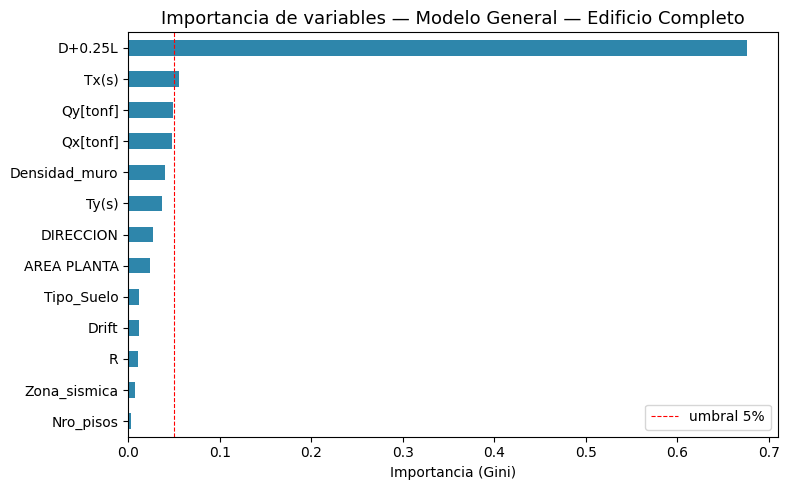

     Variable  Importancia
      D+0.25L     0.675942
        Tx(s)     0.055814
     Qy[tonf]     0.048448
     Qx[tonf]     0.047532
Densidad_muro     0.040156
        Ty(s)     0.037306
    DIRECCION     0.027490
  AREA PLANTA     0.023918
   Tipo_Suelo     0.011625
        Drift     0.011339
            R     0.010605
 Zona_sismica     0.007232
    Nro_pisos     0.002592


In [75]:
# ---- Importancia de variables del modelo general ----
# Se usa el modelo general del edificio completo como referencia.

def plot_importancia(modelo, nombre):
    imp = pd.Series(modelo.feature_importances_, index=variables_clf).sort_values()
    fig, ax = plt.subplots(figsize=(8, 5))
    imp.plot(kind="barh", ax=ax, color="#2E86AB")
    ax.set_title(f"Importancia de variables — {nombre}", fontsize=13)
    ax.set_xlabel("Importancia (Gini)")
    ax.axvline(x=0.05, color="red", linestyle="--", linewidth=0.8, label="umbral 5%")
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(pd.DataFrame({"Variable": variables_clf,
                        "Importancia": modelo.feature_importances_})
          .sort_values("Importancia", ascending=False).to_string(index=False))

plot_importancia(clf_g_completo, "Modelo General — Edificio Completo")

In [79]:
# ============================================================
# TABLA COMPARATIVA COMPLETA — 9 estrategias x 3 grupos
# ============================================================

from sklearn.metrics import classification_report
from imblearn.ensemble import BalancedRandomForestClassifier
import pandas as pd
import numpy as np

def obtener_f1_por_clase(y_true, y_pred, clases):
    report = classification_report(y_true, y_pred,
                                   labels=clases,
                                   target_names=clases,
                                   output_dict=True,
                                   zero_division=0)
    return {clase: round(report[clase]["f1-score"], 2) for clase in clases}

def entrenar_y_predecir_v2(dataframe, estrategia):
    df_temp = dataframe[variables_clf + [objetivo_clf]].dropna().copy()

    le_enc = {}
    for col in categoricas_clf:
        le = LabelEncoder()
        df_temp[col] = le.fit_transform(df_temp[col].astype(str))
        le_enc[col] = le

    X = df_temp[variables_clf].copy()
    y = df_temp[objetivo_clf].astype(str)
    le_t = LabelEncoder()
    y_enc = le_t.fit_transform(y)
    clases = le_t.classes_

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
    )

    y_test_str  = le_t.inverse_transform(y_test)
    y_train_str = le_t.inverse_transform(y_train)

    # ── A: Base ──────────────────────────────────────────────
    if estrategia == "A":
        clf = RandomForestClassifier(n_estimators=200, random_state=42)
        clf.fit(X_train, y_train)
        pred = le_t.inverse_transform(clf.predict(X_test))

    # ── B: RF balanced ───────────────────────────────────────
    elif estrategia == "B":
        clf = RandomForestClassifier(n_estimators=200,
                                     class_weight='balanced', random_state=42)
        clf.fit(X_train, y_train)
        pred = le_t.inverse_transform(clf.predict(X_test))

    # ── C: SMOTE-NC ──────────────────────────────────────────
    elif estrategia == "C":
        max_count = max(Counter(y_train).values())
        sampling_dict = {
            c: max(cnt, int(max_count * 0.5))
            for c, cnt in Counter(y_train).items()
        }
        smote_nc = SMOTENC(categorical_features=cat_indices,
                           sampling_strategy=sampling_dict,
                           k_neighbors=3, random_state=42)
        X_res, y_res = smote_nc.fit_resample(X_train, y_train)
        clf = RandomForestClassifier(n_estimators=200, random_state=42)
        clf.fit(X_res, y_res)
        pred = le_t.inverse_transform(clf.predict(X_test))

    # ── D: Regresión directa ─────────────────────────────────
    elif estrategia == "D":
        y_train_num = np.array([float(c) for c in y_train_str])
        y_test_num  = np.array([float(c) for c in y_test_str])
        reg = RandomForestRegressor(n_estimators=200, random_state=42)
        reg.fit(X_train, y_train_num)
        pred = np.array([str(v) for v in ajustar_a_comercial(reg.predict(X_test))])
        y_test_str = np.array([str(v) for v in ajustar_a_comercial(y_test_num)])

    # ── E: Regresión logarítmica ─────────────────────────────
    elif estrategia == "E":
        y_train_num = np.array([float(c) for c in y_train_str])
        y_test_num  = np.array([float(c) for c in y_test_str])
        reg = RandomForestRegressor(n_estimators=200, random_state=42)
        reg.fit(X_train, np.log(y_train_num))
        pred = np.array([str(v) for v in ajustar_a_comercial(np.exp(reg.predict(X_test)))])
        y_test_str = np.array([str(v) for v in ajustar_a_comercial(y_test_num)])

    # ── F: XGBoost balanced ──────────────────────────────────
    elif estrategia == "F":
        cols_limpias = [c.replace('[','').replace(']','')
                         .replace('<','').replace('>','')
                        for c in variables_clf]
        X_train_xgb = X_train.copy(); X_train_xgb.columns = cols_limpias
        X_test_xgb  = X_test.copy();  X_test_xgb.columns  = cols_limpias
        sw = compute_sample_weight('balanced', y_train)
        clf = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                            eval_metric='mlogloss', random_state=42, n_jobs=-1)
        clf.fit(X_train_xgb, y_train, sample_weight=sw)
        pred = le_t.inverse_transform(clf.predict(X_test_xgb))

    # ── G: SMOTE-NC + XGBoost ────────────────────────────────
    elif estrategia == "G":
        cols_limpias = [c.replace('[','').replace(']','')
                         .replace('<','').replace('>','')
                        for c in variables_clf]
        cat_idx_xgb = [cols_limpias.index(
            c.replace('[','').replace(']','').replace('<','').replace('>',''))
            for c in categoricas_clf]
        X_train_xgb = X_train.copy(); X_train_xgb.columns = cols_limpias
        X_test_xgb  = X_test.copy();  X_test_xgb.columns  = cols_limpias
        smote_nc = SMOTENC(categorical_features=cat_idx_xgb,
                           k_neighbors=3, random_state=42)
        X_res, y_res = smote_nc.fit_resample(X_train_xgb, y_train)
        clf = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                            eval_metric='mlogloss', random_state=42, n_jobs=-1)
        clf.fit(X_res, y_res)
        pred = le_t.inverse_transform(clf.predict(X_test_xgb))

    # ── H: Balanced RF ajuste manual ─────────────────────────
    elif estrategia == "H":
        clf = BalancedRandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=1,
            sampling_strategy='not majority',
            replacement=False,
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1
        )
        clf.fit(X_train, y_train_str)
        pred = clf.predict(X_test)
        y_test_str = y_test_str

    # ── I: Cascada ───────────────────────────────────────────
    elif estrategia == "I":
        clf_g = RandomForestClassifier(n_estimators=200, random_state=42)
        clf_g.fit(X_train, y_train_str)
        mask_tr = pd.Series(y_train_str).isin(DIAMETROS_DIFICILES).values
        clf_e = RandomForestClassifier(n_estimators=200,
                                       class_weight='balanced', random_state=42)
        clf_e.fit(X_train[mask_tr], y_train_str[mask_tr])
        pred_g  = clf_g.predict(X_test)
        mask_d  = np.isin(pred_g, DIAMETROS_DIFICILES)
        pred    = pred_g.copy()
        if mask_d.sum() > 0:
            pred[mask_d] = clf_e.predict(X_test[mask_d])

    clases_str = sorted(np.unique(np.concatenate([y_test_str, pred])),
                        key=lambda x: float(x))
    acc = np.mean(pred == y_test_str)
    f1  = obtener_f1_por_clase(y_test_str, pred, clases_str)
    return f1, acc, clases_str


# ---- Construir tabla para un grupo ----
def construir_tabla_grupo(dataframe, nombre_grupo):
    estrategias = {
        "A — Base":                        "A",
        "B — RF balanced":                 "B",
        "C — SMOTE-NC":                    "C",
        "D — Regresión directa":           "D",
        "E — Regresión logarítmica":       "E",
        "F — XGBoost balanced":            "F",
        "G — SMOTE-NC + XGBoost":          "G",
        "H — Balanced RF ajuste manual":   "H",
        "I — Cascada ":                  "I",
    }

    filas = {}
    accuracies = {}
    clases_ref = None

    for nombre_est, letra in estrategias.items():
        f1, acc, clases = entrenar_y_predecir_v2(dataframe, letra)
        filas[nombre_est] = f1
        accuracies[nombre_est] = acc
        if clases_ref is None:
            clases_ref = clases

    tabla = pd.DataFrame(filas, index=clases_ref).T
    tabla.insert(0, "Accuracy", [accuracies[e] for e in estrategias.keys()])

    print(f"\n{'█'*70}")
    print(f"   F1-SCORE POR DIÁMETRO — {nombre_grupo}")
    print(f"{'█'*70}")
    print(tabla.to_string(float_format="{:.2f}".format))
    return tabla


# ---- Correr para los 3 grupos ----
tabla_completo = construir_tabla_grupo(df,        "EDIFICIO COMPLETO")
tabla_piso1    = construir_tabla_grupo(df_piso1,  "PISO 1")
tabla_pisos2   = construir_tabla_grupo(df_pisos2, "PISOS 2+")

# ---- Exportar a Excel ----
exportar_tablas_excel({
    "Edificio Completo": tabla_completo,
    "Piso 1":            tabla_piso1,
    "Pisos 2+":          tabla_pisos2,
}, nombre_archivo="comparativa_estrategias_v2.xlsx")


██████████████████████████████████████████████████████████████████████
   F1-SCORE POR DIÁMETRO — EDIFICIO COMPLETO
██████████████████████████████████████████████████████████████████████
                               Accuracy  0.9525  1.27  1.5875  1.905  2.2225  2.54  2.8575  3.175  3.4925  3.81  4.445
A — Base                           0.86    0.96  0.84    0.81   0.81    0.74  0.75    0.71   0.14    0.00  0.45   0.27
B — RF balanced                    0.84    0.96  0.84    0.81   0.83    0.72  0.69    0.65   0.43    0.34  0.40   0.40
C — SMOTE-NC                       0.85    0.96  0.84    0.80   0.81    0.72  0.71    0.65   0.43    0.35  0.40   0.32
D — Regresión directa              0.83    0.96  0.84    0.79   0.75    0.68  0.66    0.59   0.14    0.15  0.40   0.27
E — Regresión logarítmica          0.84    0.96  0.84    0.80   0.77    0.67  0.68    0.60   0.14    0.15  0.40   0.27
F — XGBoost balanced               0.84    0.96  0.84    0.81   0.83    0.72  0.69    0.65   0.45 

In [80]:
# ============================================================
# EXPORTAR TABLAS A EXCEL
# ============================================================
import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

def exportar_tablas_excel(tablas_dict, nombre_archivo="comparativa_estrategias.xlsx"):
    wb = openpyxl.Workbook()
    wb.remove(wb.active)  # eliminar hoja vacía default

    # Colores
    fill_header  = PatternFill("solid", fgColor="2E86AB")  # azul header
    fill_cascada = PatternFill("solid", fgColor="D4EDDA")  # verde fila cascada
    fill_base    = PatternFill("solid", fgColor="FFF3CD")  # amarillo fila base
    fill_alt     = PatternFill("solid", fgColor="F8F9FA")  # gris filas alternas
    font_header  = Font(bold=True, color="FFFFFF")
    font_bold    = Font(bold=True)
    borde = Border(
        left=Side(style='thin'), right=Side(style='thin'),
        top=Side(style='thin'),  bottom=Side(style='thin')
    )

    for nombre_hoja, tabla in tablas_dict.items():
        ws = wb.create_sheet(title=nombre_hoja[:31])

        # ── Título ──
        ws.merge_cells(f"A1:{get_column_letter(len(tabla.columns)+1)}1")
        ws["A1"] = f"F1-score por diámetro — {nombre_hoja}"
        ws["A1"].font = Font(bold=True, size=13)
        ws["A1"].alignment = Alignment(horizontal="center")

        # ── Headers ──
        headers = ["Estrategia", "Accuracy"] + list(tabla.columns[1:])
        for j, h in enumerate(headers, 1):
            cell = ws.cell(row=2, column=j, value=h)
            cell.fill   = fill_header
            cell.font   = font_header
            cell.alignment = Alignment(horizontal="center")
            cell.border = borde

        # ── Datos ──
        for i, (idx, row) in enumerate(tabla.iterrows(), 3):
            es_cascada = "Cascada" in idx
            es_base    = "Base"    in idx
            fill_fila  = fill_cascada if es_cascada else (
                         fill_base    if es_base    else (
                         fill_alt     if i % 2 == 0 else PatternFill()))

            # Nombre estrategia
            cell = ws.cell(row=i, column=1, value=idx)
            cell.fill   = fill_fila
            cell.font   = font_bold if es_cascada else Font()
            cell.border = borde

            # Accuracy
            cell = ws.cell(row=i, column=2, value=round(row["Accuracy"], 4))
            cell.number_format = "0.00%"
            cell.fill   = fill_fila
            cell.border = borde
            cell.alignment = Alignment(horizontal="center")

            # F1 por diámetro
            for j, col in enumerate(tabla.columns[1:], 3):
                val  = row[col]
                cell = ws.cell(row=i, column=j, value=round(val, 2))
                cell.border = borde
                cell.alignment = Alignment(horizontal="center")

                # Colorear celda según valor F1
                if val >= 0.80:
                    cell.fill = PatternFill("solid", fgColor="C6EFCE")  # verde
                elif val >= 0.60:
                    cell.fill = PatternFill("solid", fgColor="FFEB9C")  # amarillo
                else:
                    cell.fill = PatternFill("solid", fgColor="FFC7CE")  # rojo

        # ── Ajustar ancho columnas ──
        for col in ws.columns:
            max_len = max(len(str(cell.value or "")) for cell in col)
            ws.column_dimensions[get_column_letter(col[0].column)].width = max_len + 4

    wb.save(nombre_archivo)
    print(f"✅ Tabla exportada: {nombre_archivo}")

# ---- Exportar ----
exportar_tablas_excel({
    "Edificio Completo": tabla_completo,
    "Piso 1":            tabla_piso1,
    "Pisos 2+":          tabla_pisos2,
}, nombre_archivo="comparativa_estrategias.xlsx")
# ============================================================
# DESCARGAR EL ARCHIVO EXCEL
# ============================================================
from google.colab import files
import os

# Verificar que existe
ruta = "/content/comparativa_estrategias.xlsx"
if os.path.exists(ruta):
    print(f"✅ Archivo encontrado: {ruta}")
    print(f"   Tamaño: {os.path.getsize(ruta) / 1024:.1f} KB")
    files.download(ruta)  # ← esto abre el diálogo de descarga directamente
else:
    print("⚠️ Archivo no encontrado, revisa el nombre")

✅ Tabla exportada: comparativa_estrategias.xlsx
✅ Archivo encontrado: /content/comparativa_estrategias.xlsx
   Tamaño: 8.9 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>